## **IMPORTS**

In [53]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [54]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [55]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f'--> outputs logs in: {OUTPUT_PATH}')

--> outputs logs in: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs


## **UTILS**

### **CONFIG**

In [56]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [57]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [58]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [59]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [60]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [61]:
SCENARIO = 'optimistic'

BASE_CAR_BEHAVIOR = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

In [62]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic


In [63]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [64]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [65]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [66]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/50cars


##### *Initialisation*

In [67]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [68]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-27 23:51:34.307 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-27 23:51:34.385 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-27 23:51:34.411 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-27 23:51:34.473 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-27 23:51:34.573 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-27 23:51:34.659 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-27 23:51:34.741 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-27 23:51:34.802 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-27 23:51:34.828 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-27 23:51:34.934 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-27 23:51:34.957 | IN

##### *Metrics*

In [69]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 3.69 kWh
  Station 2: 89.96 kWh
  Station 3: 35.02 kWh
  Station 4: 102.85 kWh
  Station 5: 13.91 kWh
  Station 6: 0.00 kWh
  Station 7: 13.93 kWh
  Station 8: 0.00 kWh
  Station 9: 4.02 kWh
  Station 10: 62.52 kWh
  Station 11: 7.71 kWh
  Station 12: 3.34 kWh
  Station 13: 4.84 kWh
  Station 14: 0.00 kWh
  Station 15: 1.69 kWh
  Station 16: 1.34 kWh
  Station 17: 0.00 kWh
  Station 18: 12.85 kWh
  Station 19: 3.40 kWh
  Station 20: 1.67 kWh
  Station 21: 5.17 kWh
  Station 22: 19.90 kWh
  Station 23: 7.03 kWh
  Station 24: 1.80 kWh
  Station 25: 7.29 kWh
  Station 26: 8.44 kWh
  Station 27: 0.00 kWh
  Station 28: 0.00 kWh
  Station 29: 15.92 kWh
  Station 30: 3.38 kWh
  Station 31: 62.14 kWh
  Station 32: 0.00 kWh
  Station 33: 0.00 kWh
  Station 34: 20.90 kWh
  Station 35: 44.63 kWh
  Station 36: 0.00 kWh
  Station 37: 3.87 kWh
  Station 38: 1.75 kWh
  Station 39: 0.00 kWh

--- User Requ

In [70]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

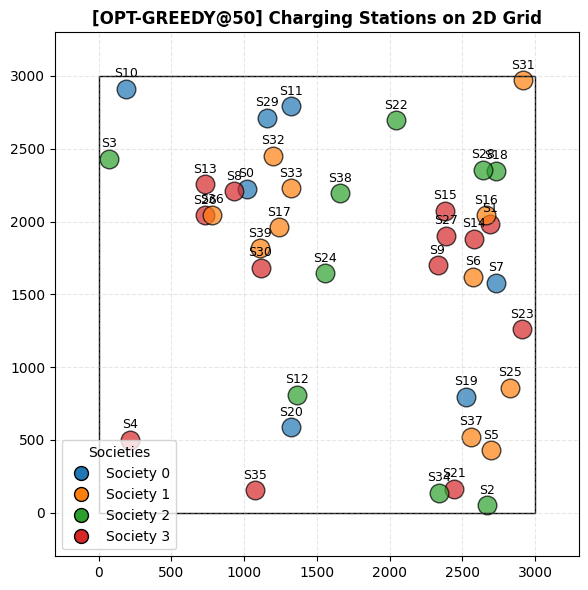

In [71]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

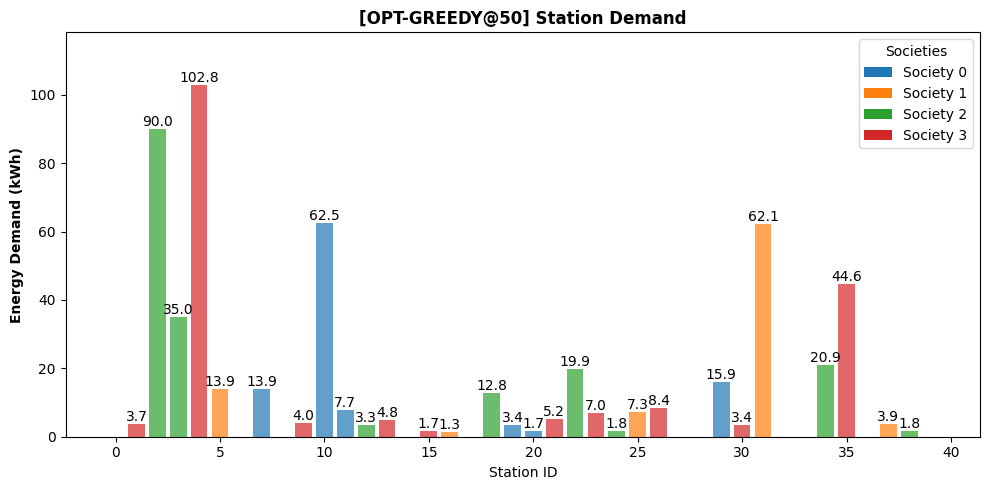

In [72]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

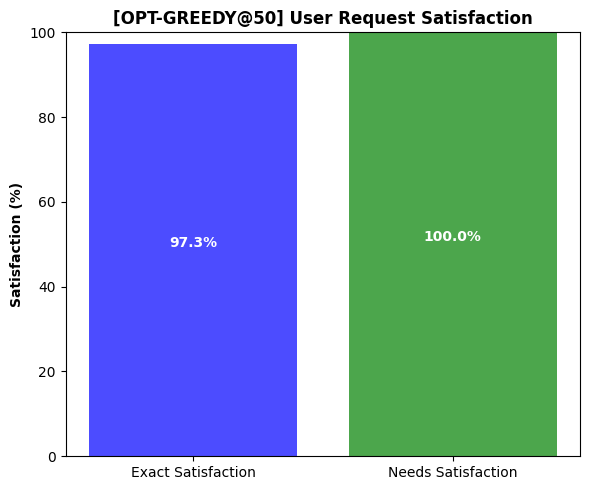

In [73]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

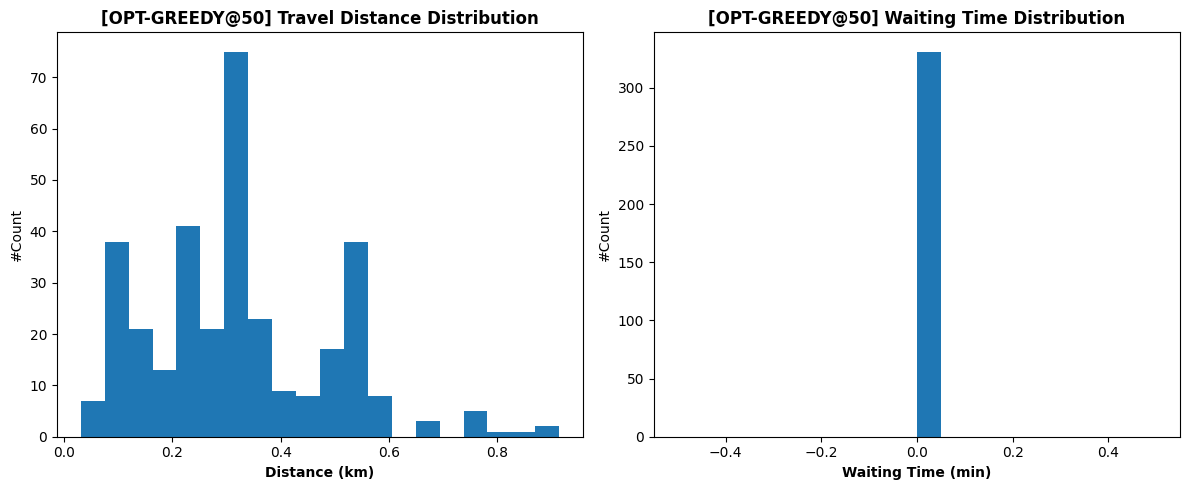

In [74]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

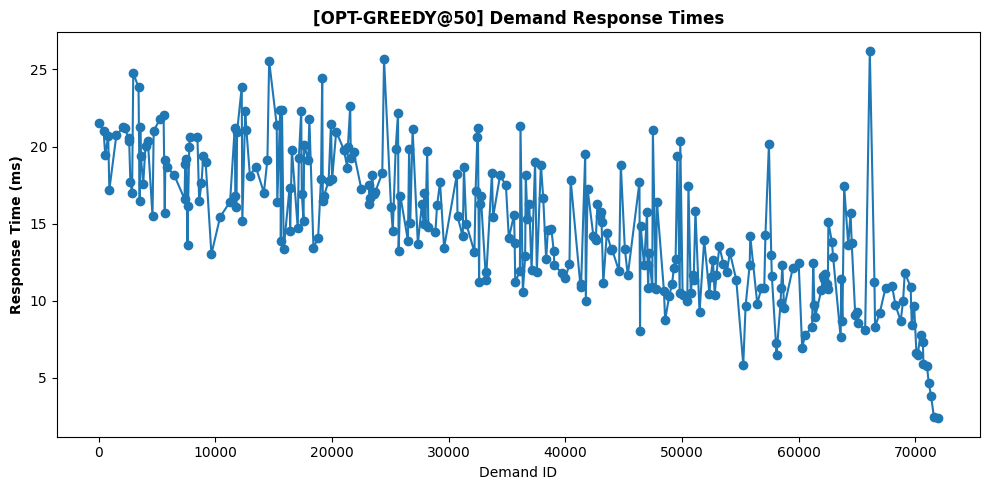

In [75]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

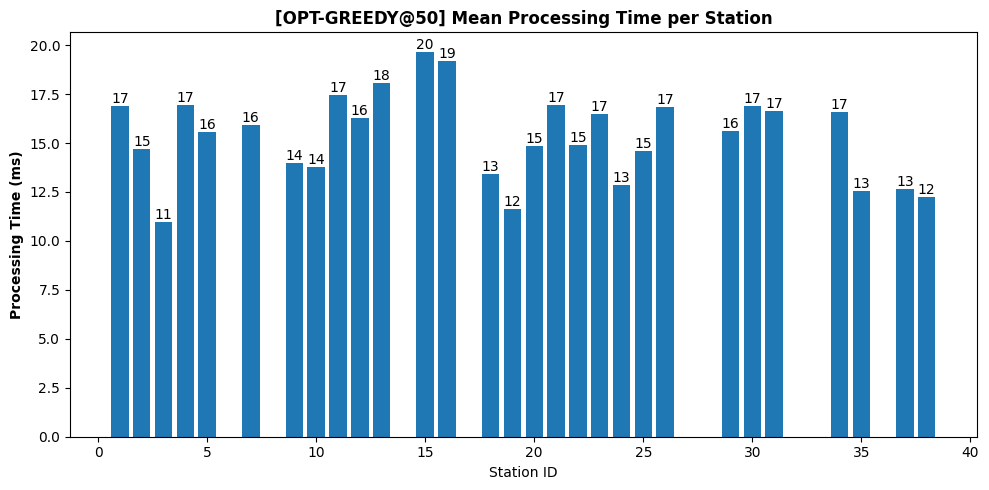

In [76]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [77]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/50cars


##### *Initialisation*

In [78]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [79]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-27 23:51:41.712 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-27 23:51:41.880 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-27 23:51:42.063 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-27 23:51:42.815 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-27 23:51:43.225 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-27 23:51:43.713 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-27 23:51:43.825 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-27 23:51:44.242 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-27 23:51:45.069 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-27 23:51:45.265 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-27 23:51:46.315 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [80]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 12.65 kWh
  Station 1: 5.44 kWh
  Station 2: 22.32 kWh
  Station 3: 1.70 kWh
  Station 4: 11.08 kWh
  Station 5: 0.00 kWh
  Station 6: 6.71 kWh
  Station 7: 4.23 kWh
  Station 8: 69.97 kWh
  Station 9: 0.00 kWh
  Station 10: 7.79 kWh
  Station 11: 22.72 kWh
  Station 12: 18.26 kWh
  Station 13: 3.30 kWh
  Station 14: 9.18 kWh
  Station 15: 16.30 kWh
  Station 16: 29.33 kWh
  Station 17: 1.45 kWh
  Station 18: 8.91 kWh
  Station 19: 3.01 kWh
  Station 20: 10.58 kWh
  Station 21: 68.10 kWh
  Station 22: 1.75 kWh
  Station 23: 6.36 kWh
  Station 24: 1.25 kWh
  Station 25: 0.00 kWh
  Station 26: 9.45 kWh
  Station 27: 4.29 kWh
  Station 28: 3.70 kWh
  Station 29: 3.62 kWh
  Station 30: 13.11 kWh
  Station 31: 0.00 kWh
  Station 32: 1.63 kWh
  Station 33: 19.88 kWh
  Station 34: 46.15 kWh
  Station 35: 73.02 kWh
  Station 36: 22.56 kWh
  Station 37: 1.50 kWh
  Station 38: 10.27 kWh
  Station 39: 10.62 kWh

--- User 

In [81]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

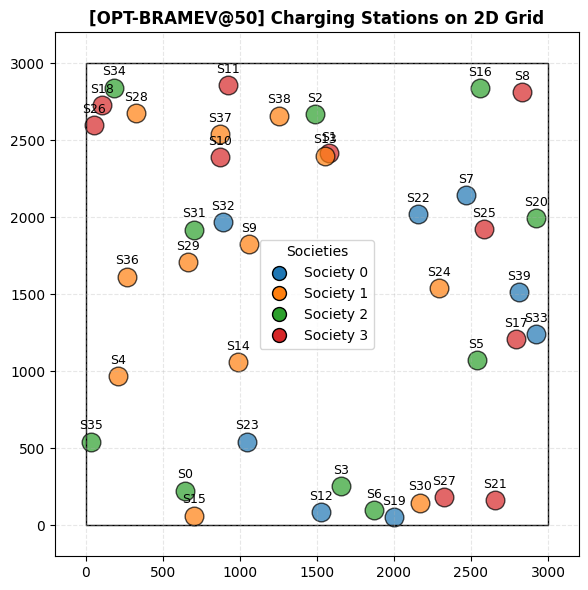

In [82]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

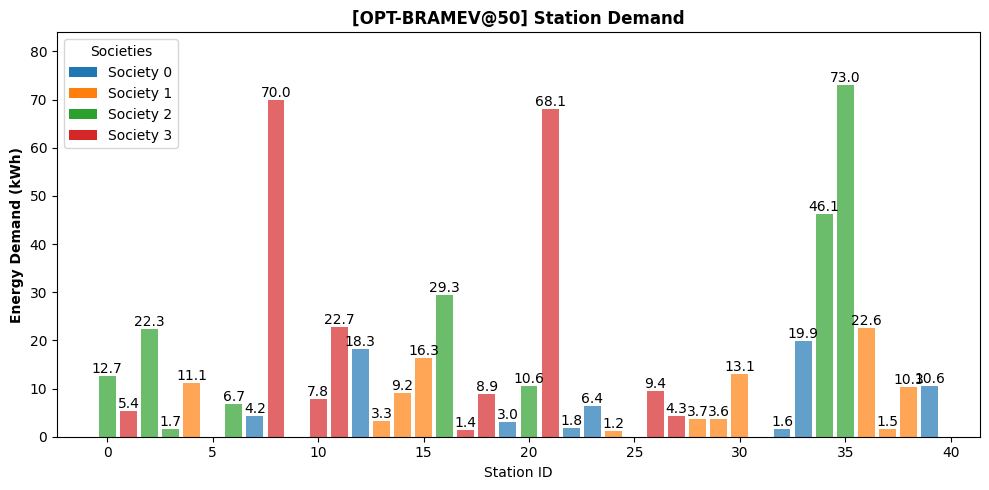

In [83]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

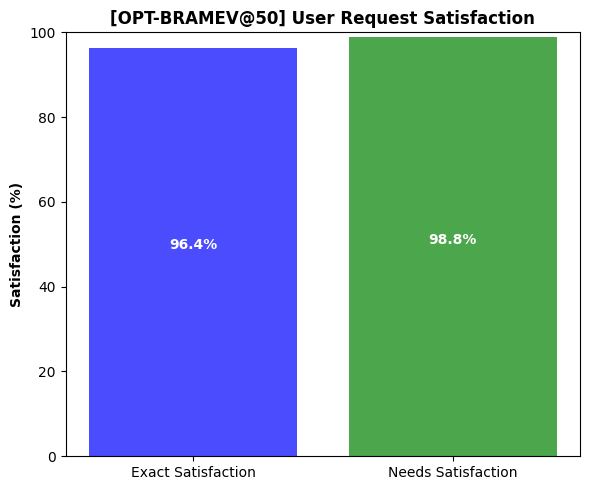

In [84]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

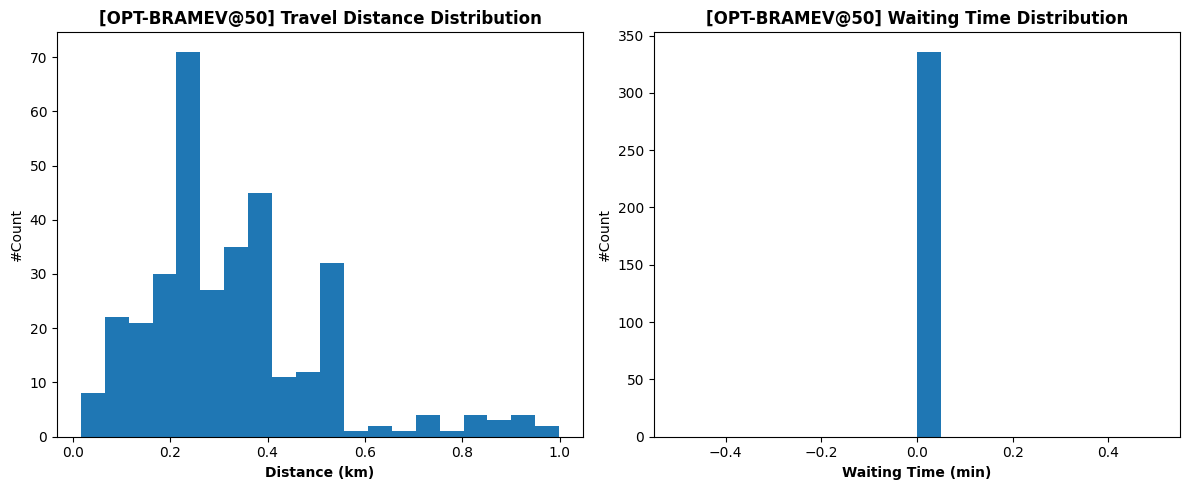

In [85]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

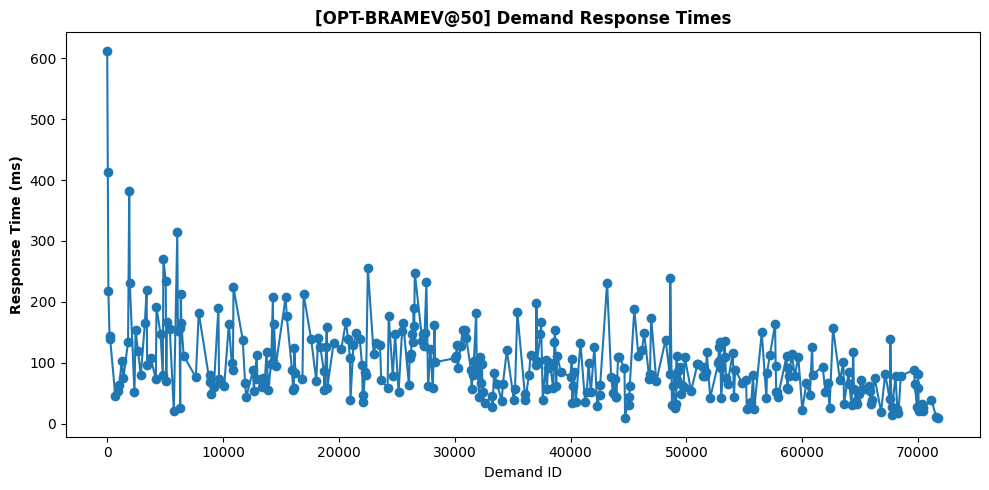

In [86]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

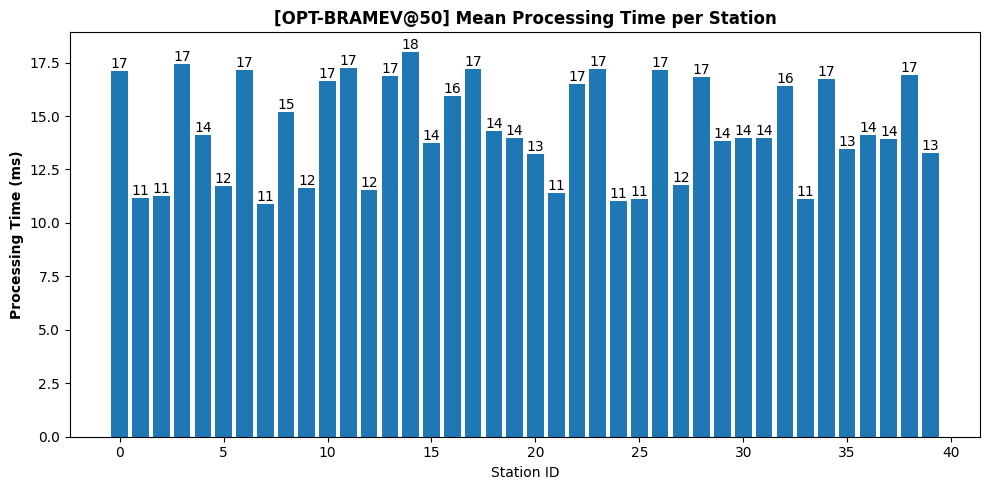

In [87]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [88]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

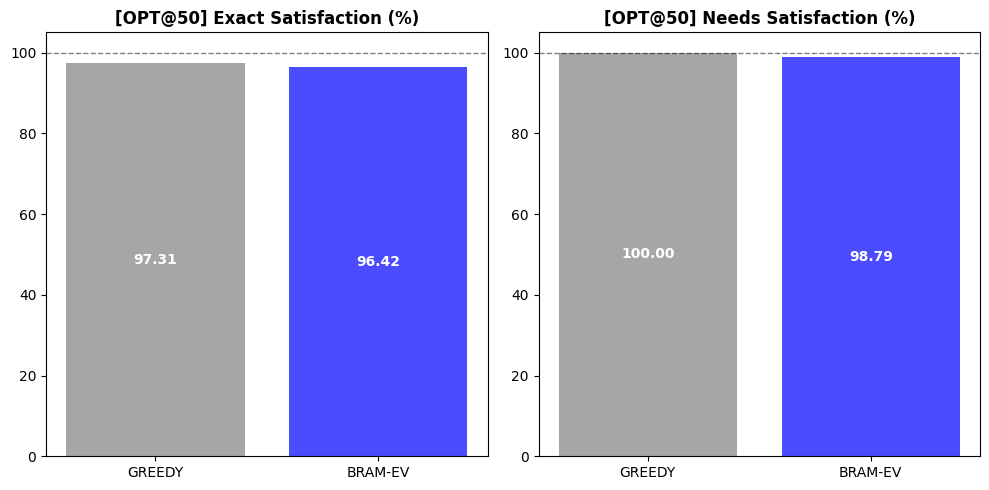

In [89]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

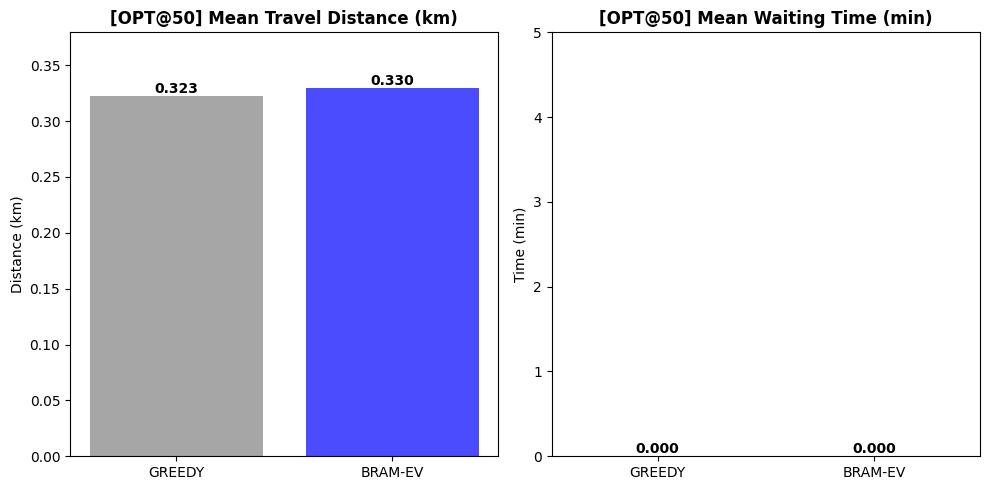

In [90]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

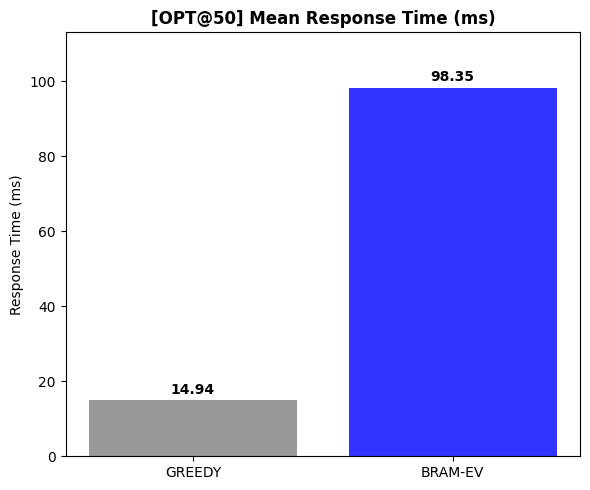

In [91]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [92]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [93]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/100cars


##### *Initialisation*

In [94]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [95]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-27 23:52:14.433 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-27 23:52:14.654 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-27 23:52:14.694 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-27 23:52:14.896 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-27 23:52:15.018 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-27 23:52:15.134 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-27 23:52:15.335 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-27 23:52:15.436 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-27 23:52:15.628 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-27 23:52:15.726 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-27 23:52:15.820 | IN

##### *Metrics*

In [96]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 7.21 kWh
  Station 1: 4.47 kWh
  Station 2: 35.80 kWh
  Station 3: 35.58 kWh
  Station 4: 8.96 kWh
  Station 5: 149.15 kWh
  Station 6: 29.54 kWh
  Station 7: 2.23 kWh
  Station 8: 0.00 kWh
  Station 9: 22.88 kWh
  Station 10: 33.65 kWh
  Station 11: 14.57 kWh
  Station 12: 12.09 kWh
  Station 13: 5.50 kWh
  Station 14: 4.87 kWh
  Station 15: 152.24 kWh
  Station 16: 31.43 kWh
  Station 17: 43.77 kWh
  Station 18: 26.74 kWh
  Station 19: 6.97 kWh
  Station 20: 1.67 kWh
  Station 21: 25.22 kWh
  Station 22: 3.88 kWh
  Station 23: 9.23 kWh
  Station 24: 7.90 kWh
  Station 25: 38.00 kWh
  Station 26: 5.55 kWh
  Station 27: 160.31 kWh
  Station 28: 1.28 kWh
  Station 29: 28.74 kWh
  Station 30: 9.28 kWh
  Station 31: 129.21 kWh
  Station 32: 15.70 kWh
  Station 33: 3.00 kWh
  Station 34: 5.83 kWh
  Station 35: 13.09 kWh
  Station 36: 19.88 kWh
  Station 37: 15.71 kWh
  Station 38: 1.58 kWh
  Station 39: 4.02 kWh

-

In [97]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

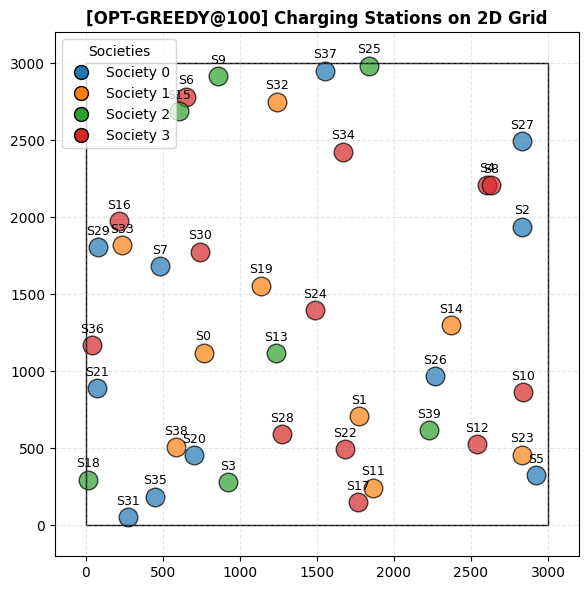

In [98]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

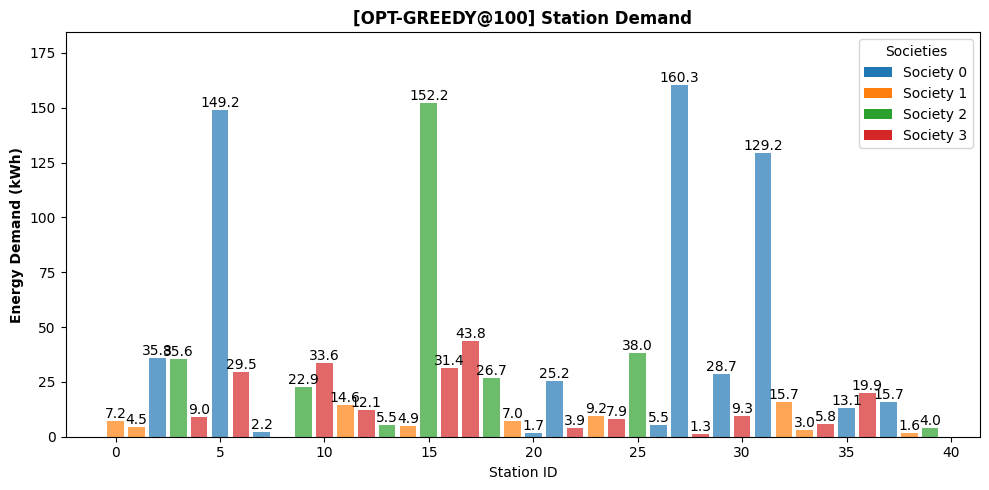

In [99]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

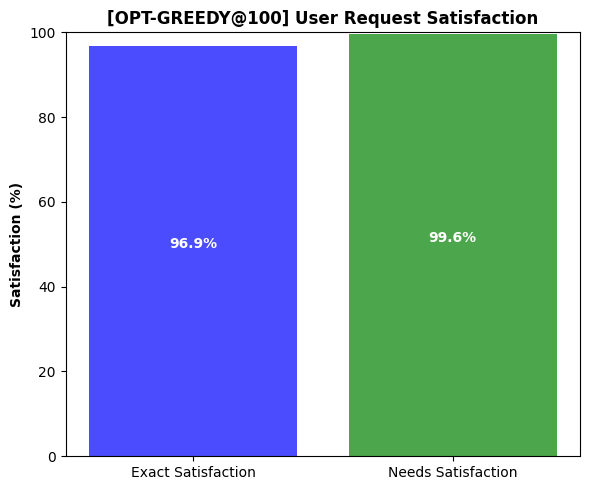

In [100]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

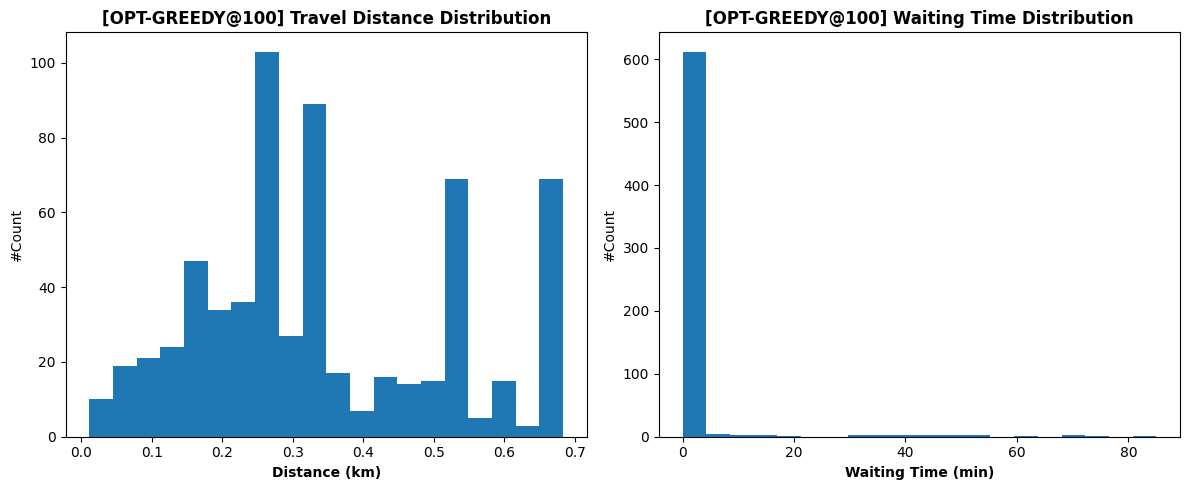

In [101]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

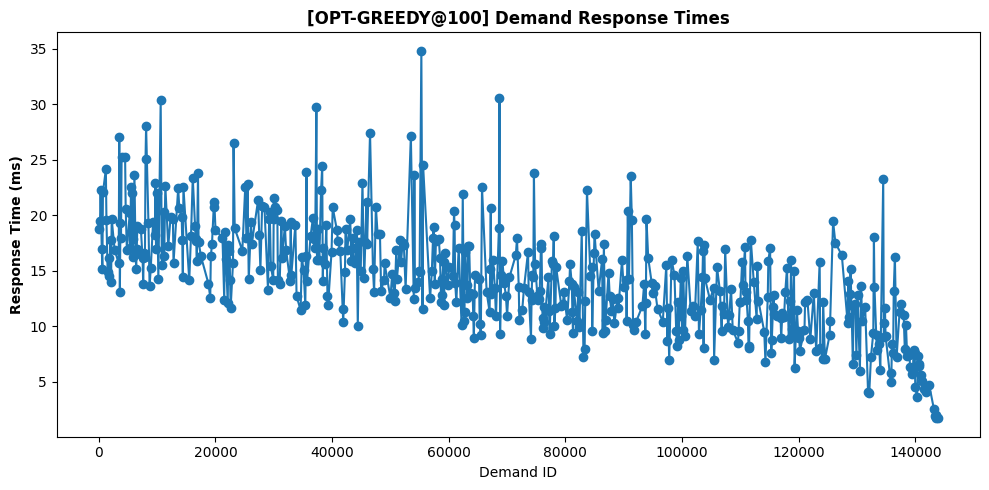

In [102]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

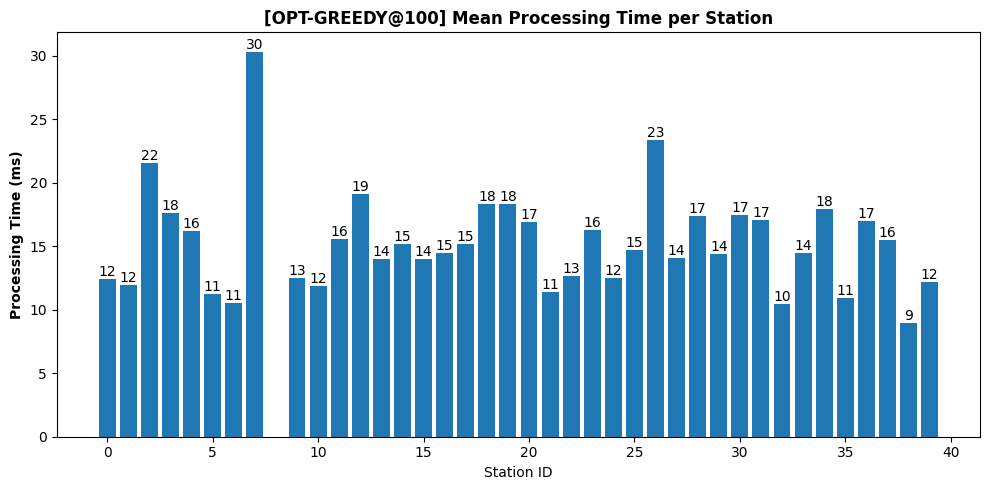

In [103]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [104]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/100cars


##### *Initialisation*

In [105]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [106]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-27 23:52:29.108 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-27 23:52:29.560 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-27 23:52:29.912 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-27 23:52:30.198 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-27 23:52:30.923 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-27 23:52:32.018 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-27 23:52:32.521 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-27 23:52:33.762 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-27 23:52:34.261 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-27 23:52:35.528 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-27 23:52:36.246 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [107]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 17.32 kWh
  Station 1: 0.00 kWh
  Station 2: 9.57 kWh
  Station 3: 58.70 kWh
  Station 4: 4.25 kWh
  Station 5: 35.62 kWh
  Station 6: 16.56 kWh
  Station 7: 122.17 kWh
  Station 8: 20.85 kWh
  Station 9: 51.97 kWh
  Station 10: 6.31 kWh
  Station 11: 13.06 kWh
  Station 12: 10.81 kWh
  Station 13: 29.89 kWh
  Station 14: 5.50 kWh
  Station 15: 40.38 kWh
  Station 16: 3.05 kWh
  Station 17: 5.88 kWh
  Station 18: 127.68 kWh
  Station 19: 3.35 kWh
  Station 20: 58.72 kWh
  Station 21: 1.67 kWh
  Station 22: 5.22 kWh
  Station 23: 41.30 kWh
  Station 24: 10.53 kWh
  Station 25: 3.63 kWh
  Station 26: 11.45 kWh
  Station 27: 2.74 kWh
  Station 28: 101.41 kWh
  Station 29: 6.79 kWh
  Station 30: 16.71 kWh
  Station 31: 115.86 kWh
  Station 32: 57.55 kWh
  Station 33: 3.83 kWh
  Station 34: 7.87 kWh
  Station 35: 32.73 kWh
  Station 36: 22.87 kWh
  Station 37: 21.52 kWh
  Station 38: 12.36 kWh
  Station 39: 2.98 kWh

In [108]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

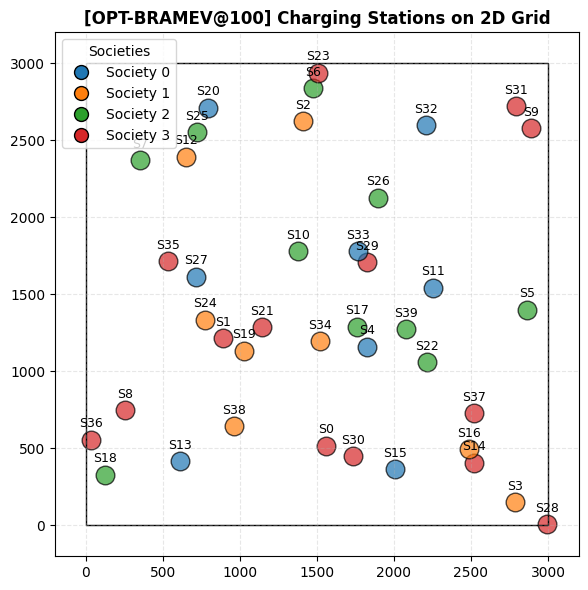

In [109]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

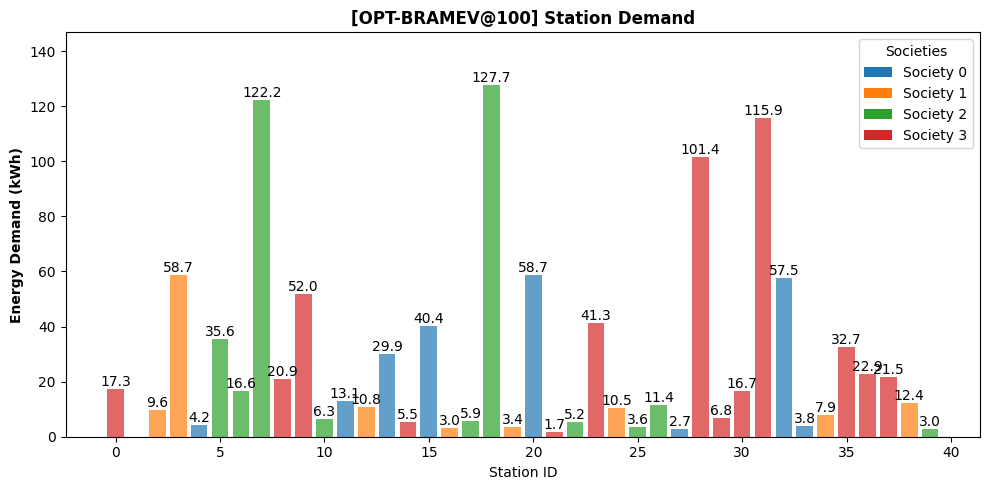

In [110]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

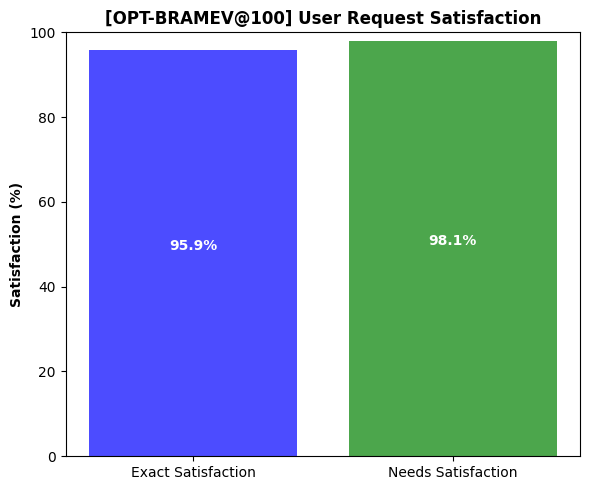

In [111]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

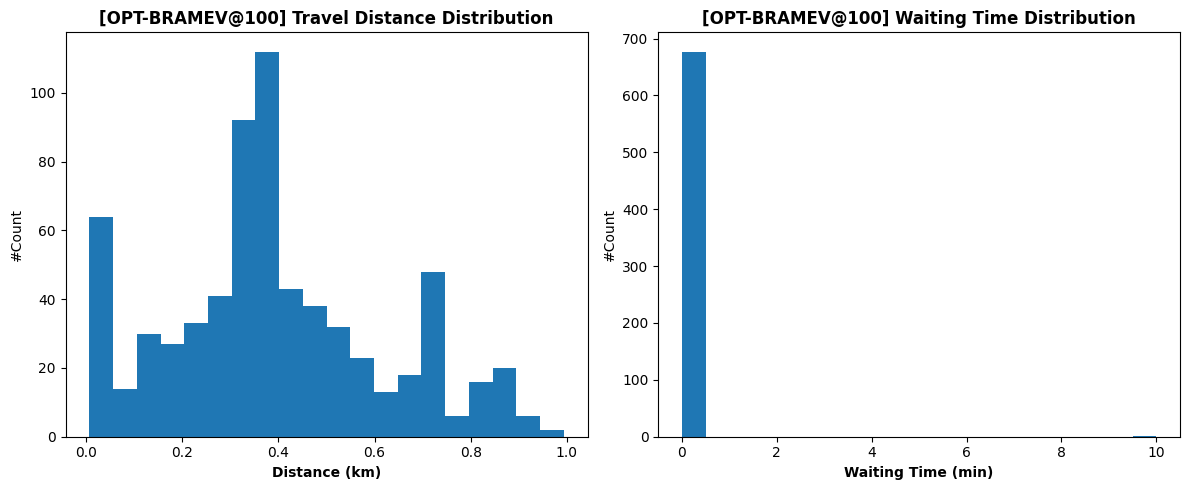

In [112]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

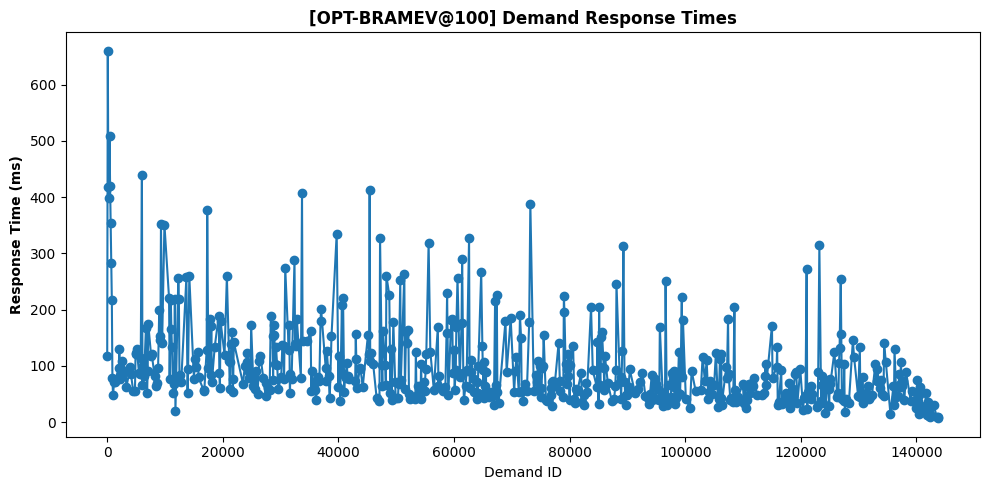

In [113]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

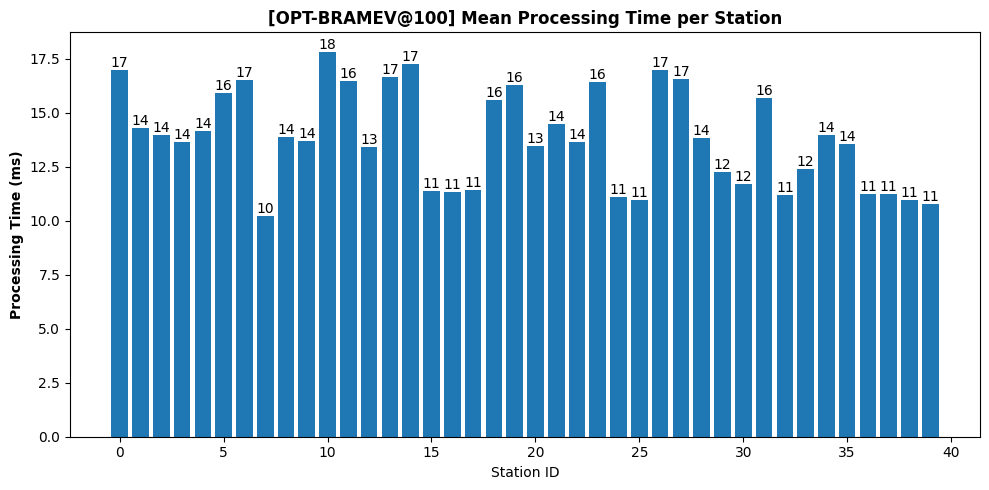

In [114]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [115]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

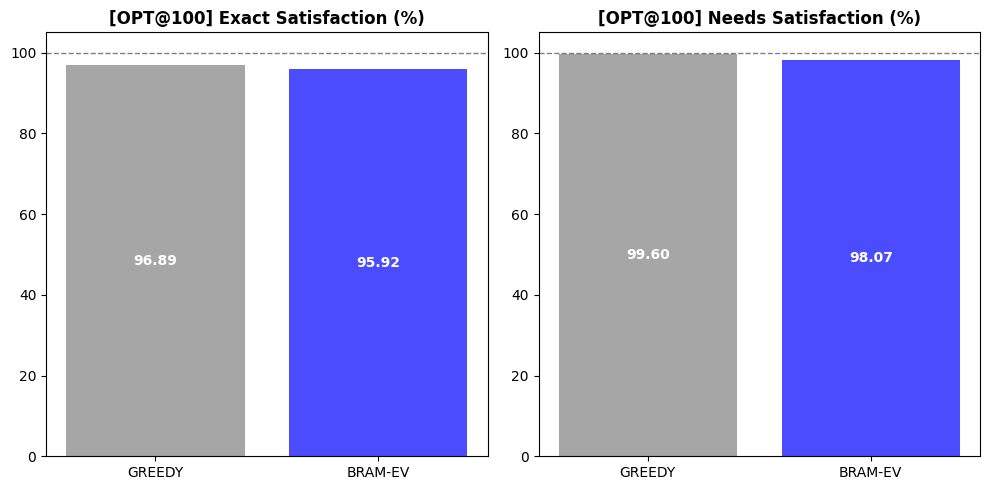

In [116]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

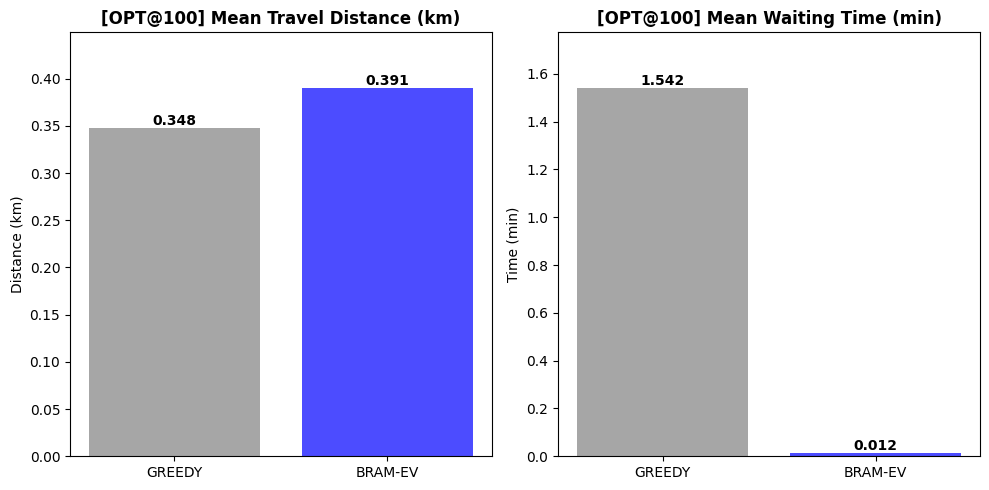

In [117]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

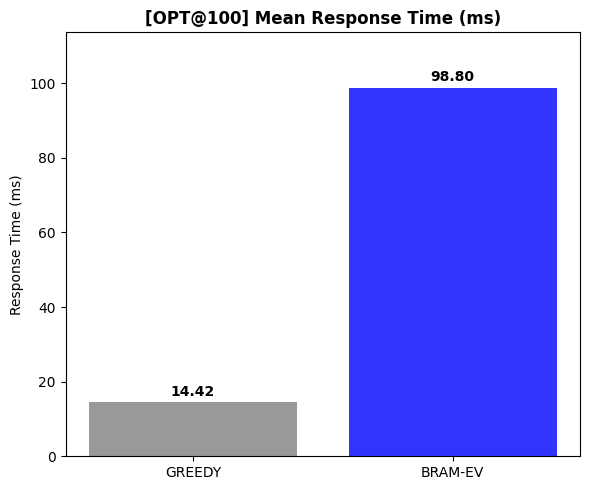

In [118]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [119]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [120]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/150cars


##### *Initialisation*

In [121]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [122]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-27 23:53:25.957 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-27 23:53:26.154 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-27 23:53:26.279 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-27 23:53:26.394 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-27 23:53:26.594 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-27 23:53:26.808 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-27 23:53:27.053 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-27 23:53:27.229 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-27 23:53:27.462 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-27 23:53:27.639 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-27 23:53:27.803 | IN

##### *Metrics*

In [123]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 43.26 kWh
  Station 1: 21.07 kWh
  Station 2: 224.87 kWh
  Station 3: 6.65 kWh
  Station 4: 51.01 kWh
  Station 5: 233.79 kWh
  Station 6: 232.18 kWh
  Station 7: 49.05 kWh
  Station 8: 23.36 kWh
  Station 9: 5.62 kWh
  Station 10: 22.07 kWh
  Station 11: 2.53 kWh
  Station 12: 13.78 kWh
  Station 13: 1.80 kWh
  Station 14: 10.15 kWh
  Station 15: 24.07 kWh
  Station 16: 2.53 kWh
  Station 17: 69.12 kWh
  Station 18: 70.85 kWh
  Station 19: 57.08 kWh
  Station 20: 5.34 kWh
  Station 21: 2.25 kWh
  Station 22: 220.24 kWh
  Station 23: 36.52 kWh
  Station 24: 8.85 kWh
  Station 25: 6.65 kWh
  Station 26: 30.89 kWh
  Station 27: 7.37 kWh
  Station 28: 16.00 kWh
  Station 29: 6.30 kWh
  Station 30: 52.81 kWh
  Station 31: 3.33 kWh
  Station 32: 7.29 kWh
  Station 33: 4.57 kWh
  Station 34: 6.22 kWh
  Station 35: 0.00 kWh
  Station 36: 5.62 kWh
  Station 37: 7.27 kWh
  Station 38: 7.66 kWh
  Station 39: 48.29 kWh

-

In [124]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

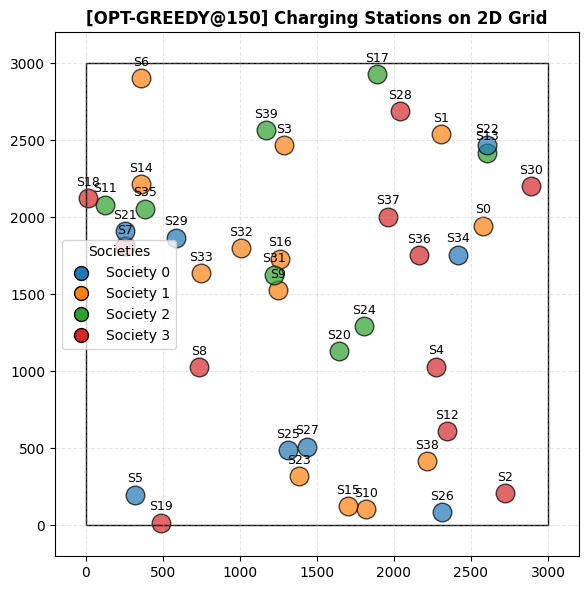

In [125]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

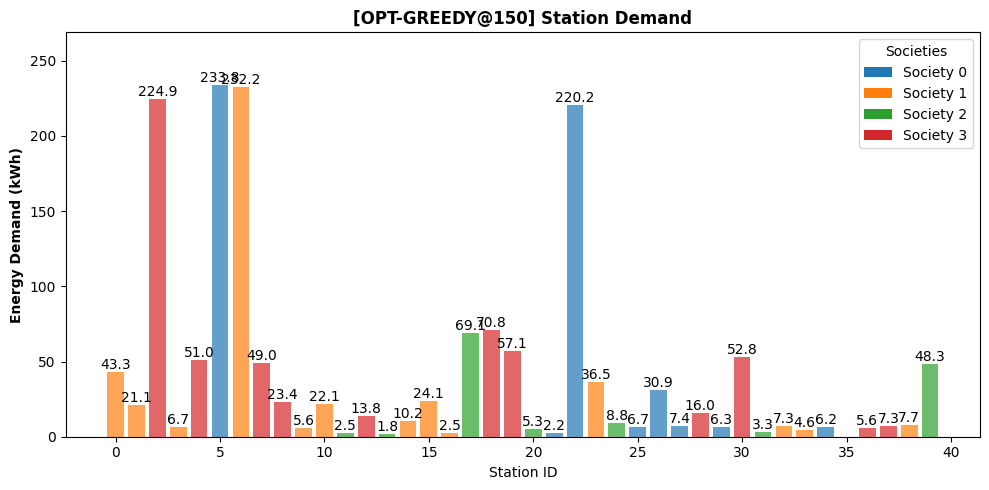

In [126]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

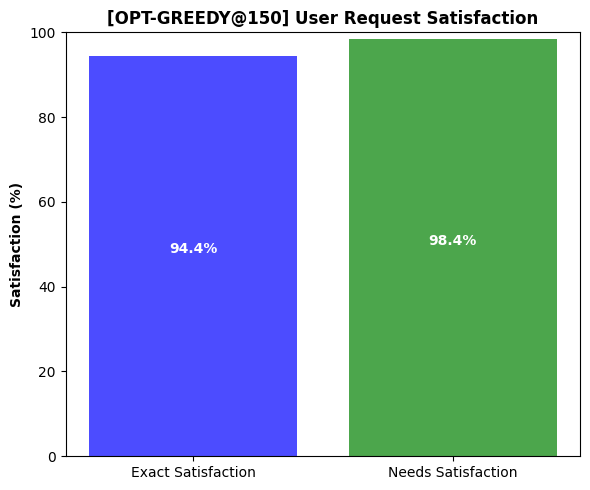

In [127]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

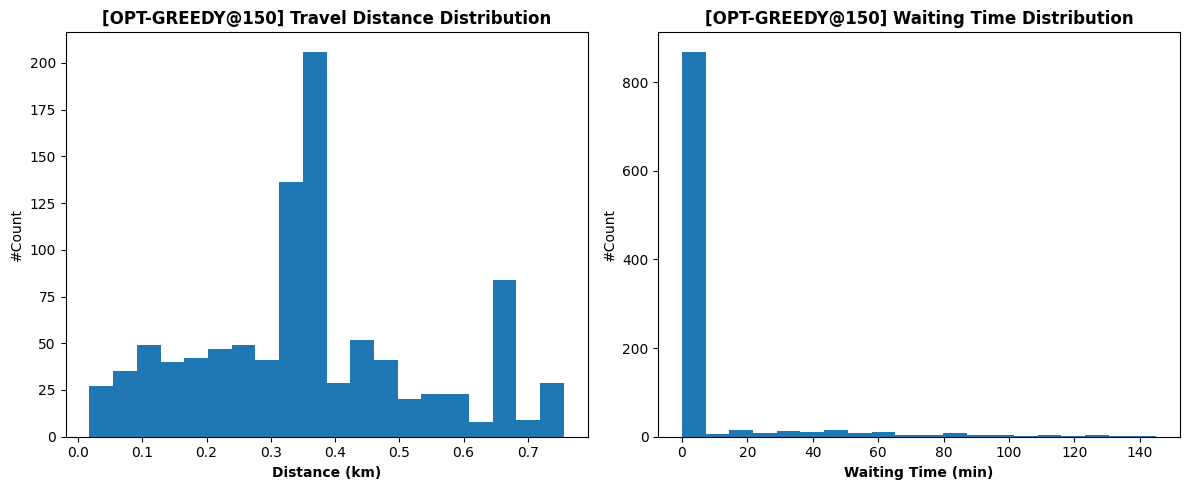

In [128]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

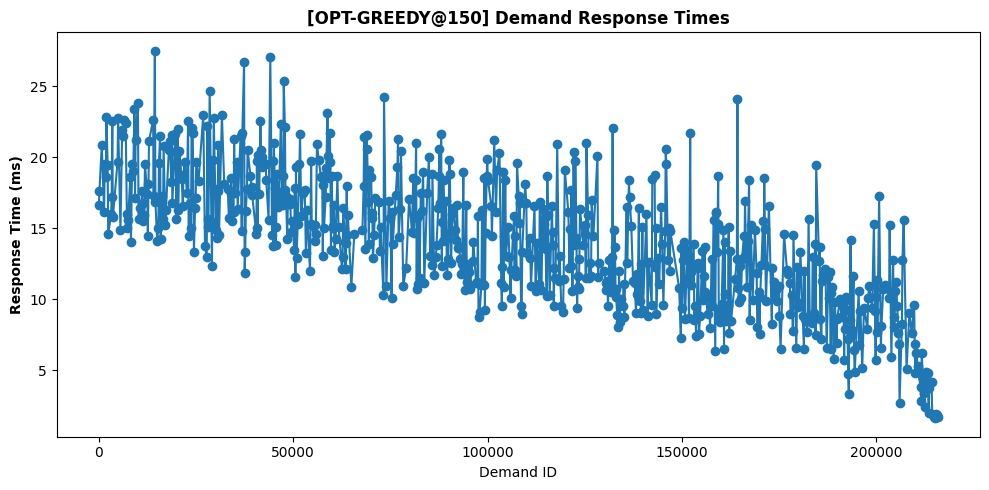

In [129]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

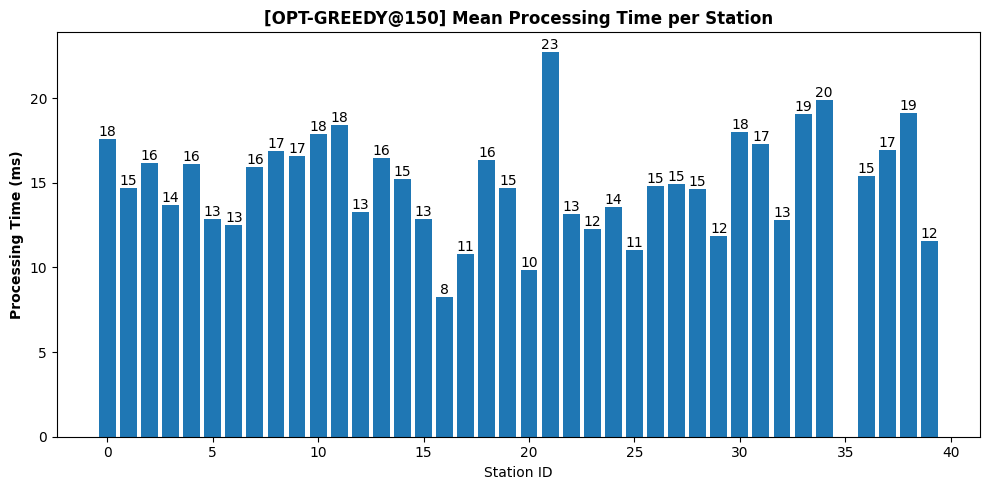

In [130]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [131]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/150cars


##### *Initialisation*

In [132]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [133]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-27 23:53:46.489 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-27 23:53:47.191 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-27 23:53:47.861 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-27 23:53:50.097 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-27 23:53:52.144 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-27 23:53:54.130 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-27 23:53:56.618 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-27 23:53:57.865 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-27 23:53:58.702 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-27 23:54:00.050 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-27 23:54:00.919 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [134]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 1.70 kWh
  Station 1: 29.93 kWh
  Station 2: 10.53 kWh
  Station 3: 54.71 kWh
  Station 4: 28.21 kWh
  Station 5: 18.86 kWh
  Station 6: 9.33 kWh
  Station 7: 35.37 kWh
  Station 8: 40.26 kWh
  Station 9: 109.76 kWh
  Station 10: 26.21 kWh
  Station 11: 1.75 kWh
  Station 12: 173.08 kWh
  Station 13: 18.07 kWh
  Station 14: 9.30 kWh
  Station 15: 70.48 kWh
  Station 16: 19.47 kWh
  Station 17: 6.69 kWh
  Station 18: 66.33 kWh
  Station 19: 180.28 kWh
  Station 20: 9.98 kWh
  Station 21: 80.55 kWh
  Station 22: 18.08 kWh
  Station 23: 31.75 kWh
  Station 24: 14.15 kWh
  Station 25: 86.28 kWh
  Station 26: 198.47 kWh
  Station 27: 8.01 kWh
  Station 28: 11.72 kWh
  Station 29: 111.33 kWh
  Station 30: 59.86 kWh
  Station 31: 6.42 kWh
  Station 32: 30.02 kWh
  Station 33: 1.30 kWh
  Station 34: 34.56 kWh
  Station 35: 9.19 kWh
  Station 36: 17.17 kWh
  Station 37: 13.94 kWh
  Station 38: 18.88 kWh
  Station 39: 10

In [135]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

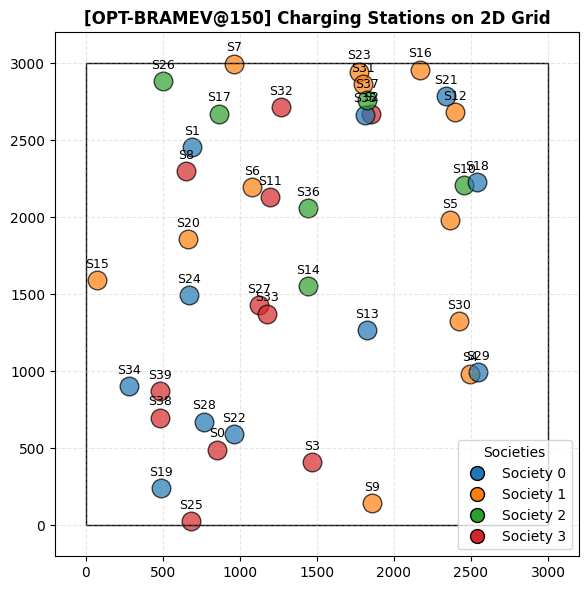

In [136]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

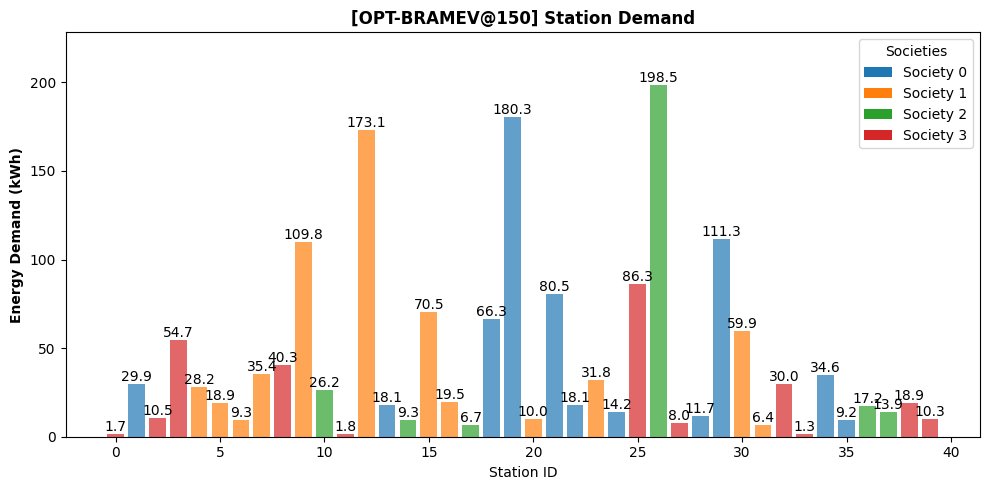

In [137]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

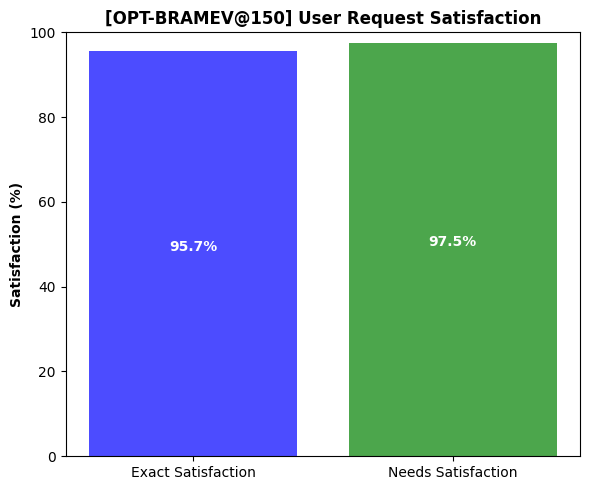

In [138]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

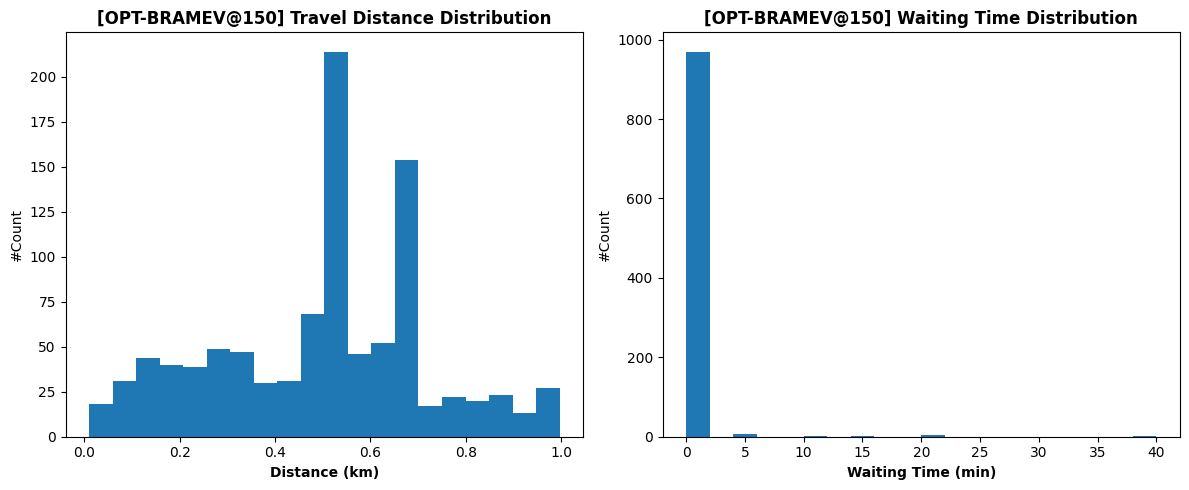

In [139]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

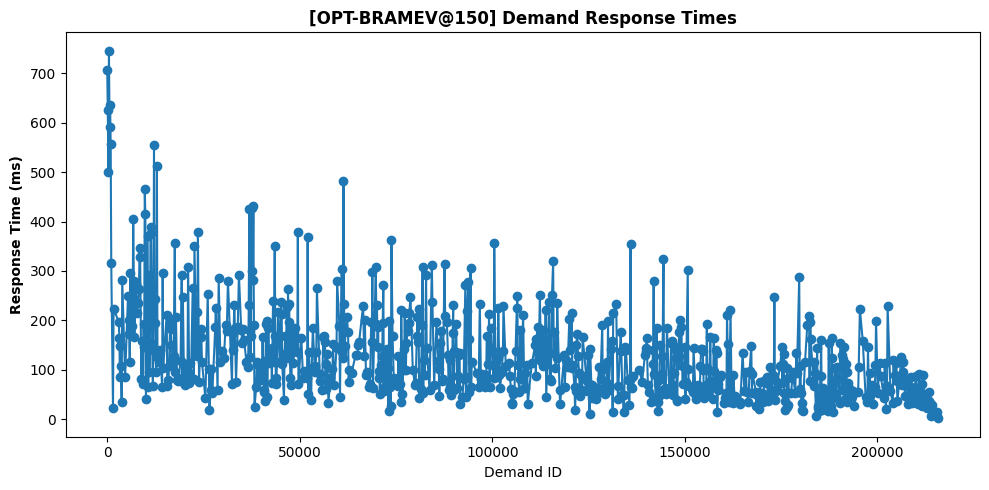

In [140]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

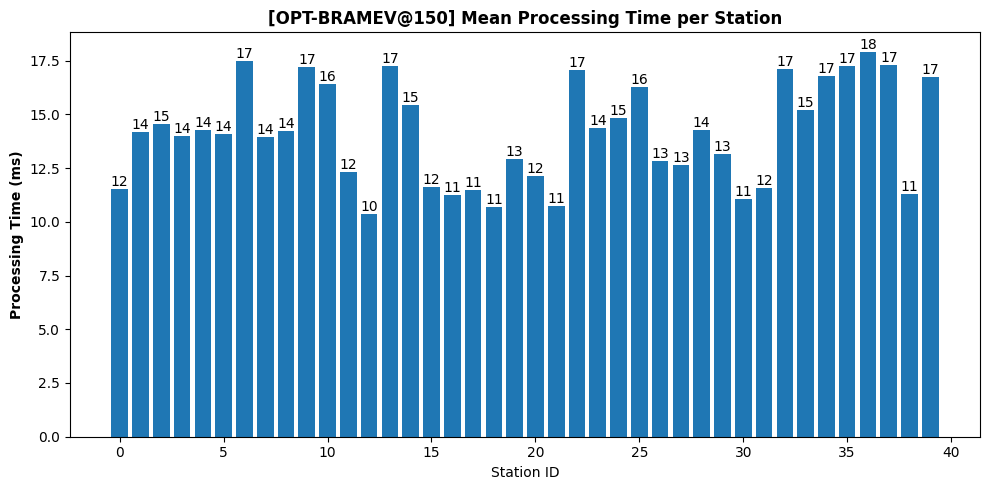

In [141]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [142]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

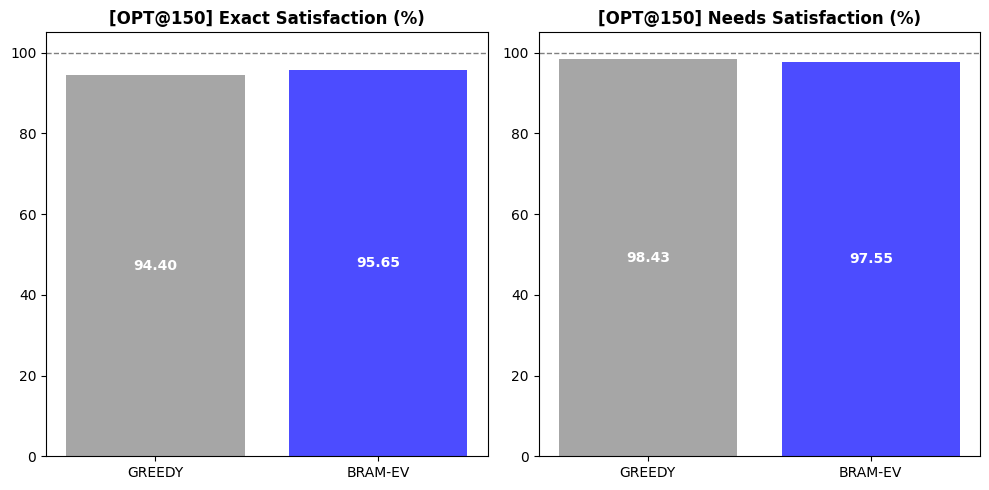

In [143]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

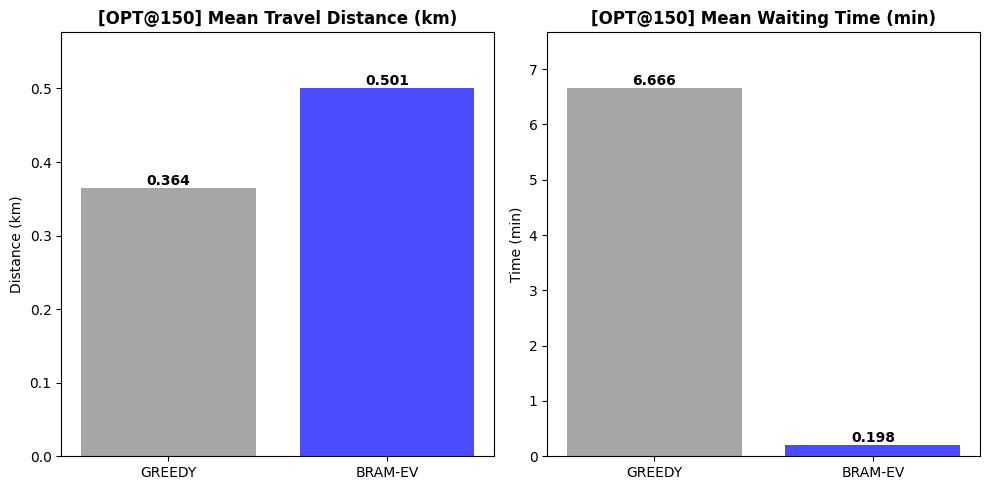

In [144]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

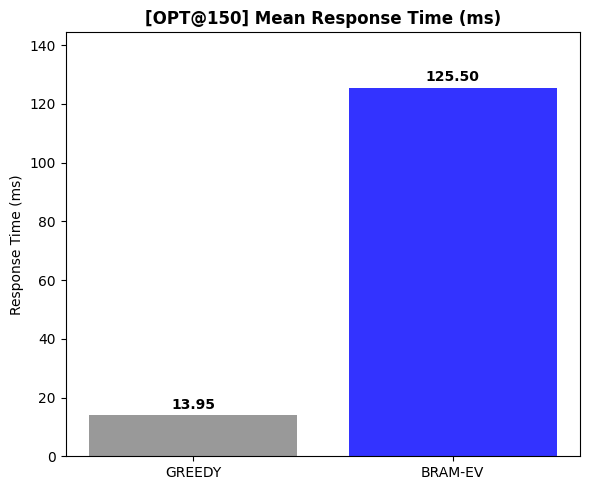

In [145]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [146]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [147]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/200cars


##### *Initialisation*

In [148]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [149]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-27 23:55:28.827 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-27 23:55:29.106 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-27 23:55:29.366 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-27 23:55:29.562 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-27 23:55:29.768 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-27 23:55:30.044 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-27 23:55:30.350 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-27 23:55:30.648 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-27 23:55:30.873 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-27 23:55:31.032 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-27 23:55:31.203 | IN

##### *Metrics*

In [150]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 78.92 kWh
  Station 1: 7.44 kWh
  Station 2: 17.26 kWh
  Station 3: 23.57 kWh
  Station 4: 6.47 kWh
  Station 5: 7.77 kWh
  Station 6: 13.42 kWh
  Station 7: 20.22 kWh
  Station 8: 105.22 kWh
  Station 9: 109.23 kWh
  Station 10: 34.54 kWh
  Station 11: 10.48 kWh
  Station 12: 276.59 kWh
  Station 13: 9.31 kWh
  Station 14: 270.73 kWh
  Station 15: 23.42 kWh
  Station 16: 13.70 kWh
  Station 17: 11.78 kWh
  Station 18: 217.41 kWh
  Station 19: 26.47 kWh
  Station 20: 54.43 kWh
  Station 21: 229.49 kWh
  Station 22: 16.77 kWh
  Station 23: 10.89 kWh
  Station 24: 7.66 kWh
  Station 25: 10.88 kWh
  Station 26: 48.76 kWh
  Station 27: 45.26 kWh
  Station 28: 73.08 kWh
  Station 29: 16.32 kWh
  Station 30: 37.98 kWh
  Station 31: 96.72 kWh
  Station 32: 7.22 kWh
  Station 33: 11.43 kWh
  Station 34: 29.65 kWh
  Station 35: 75.54 kWh
  Station 36: 18.43 kWh
  Station 37: 5.79 kWh
  Station 38: 68.79 kWh
  Station 39

In [151]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

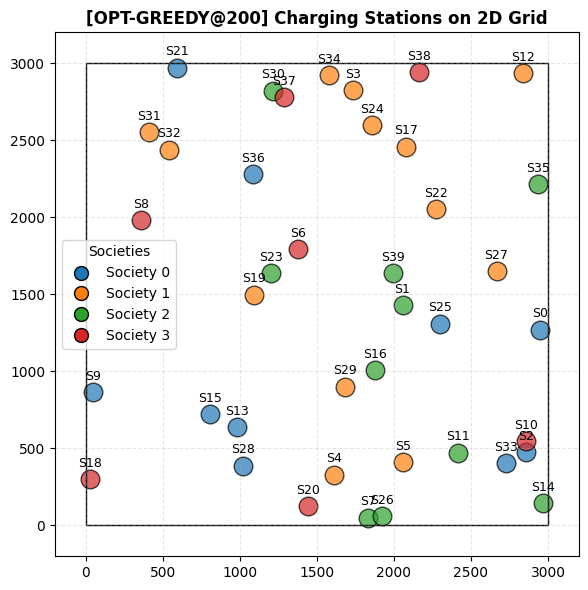

In [152]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

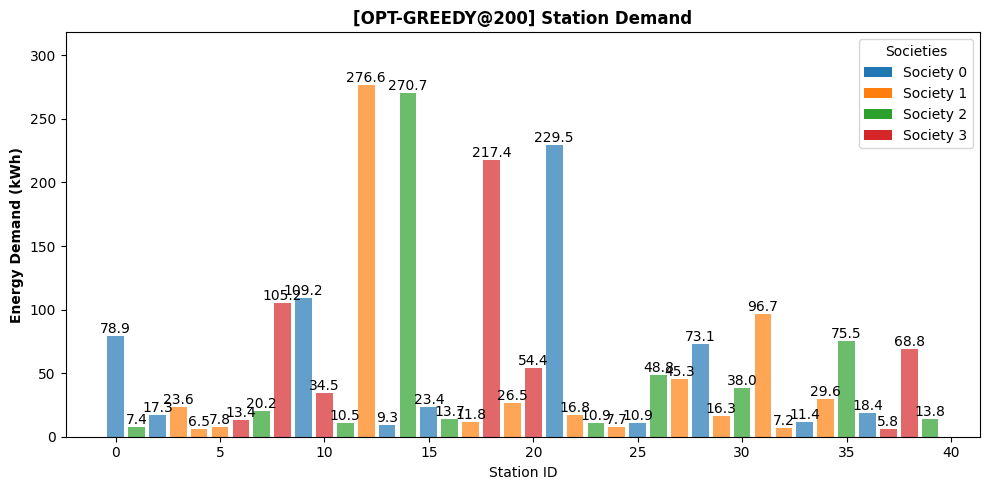

In [153]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

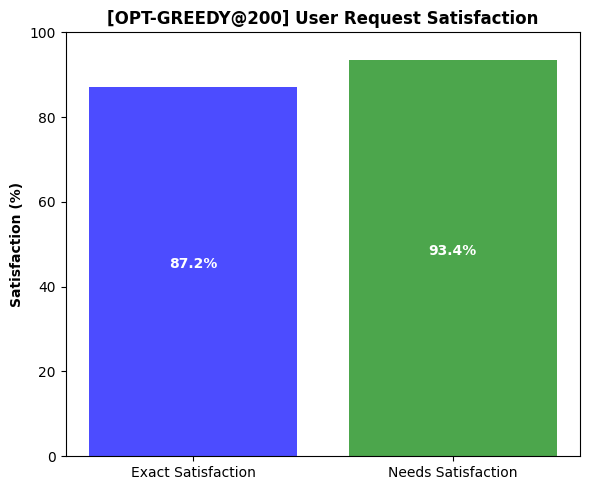

In [154]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

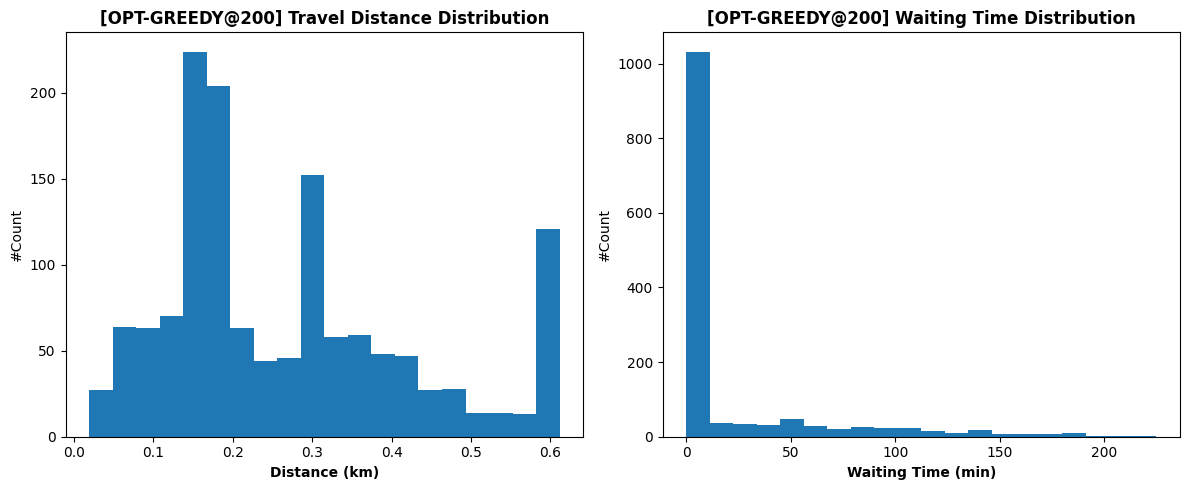

In [155]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

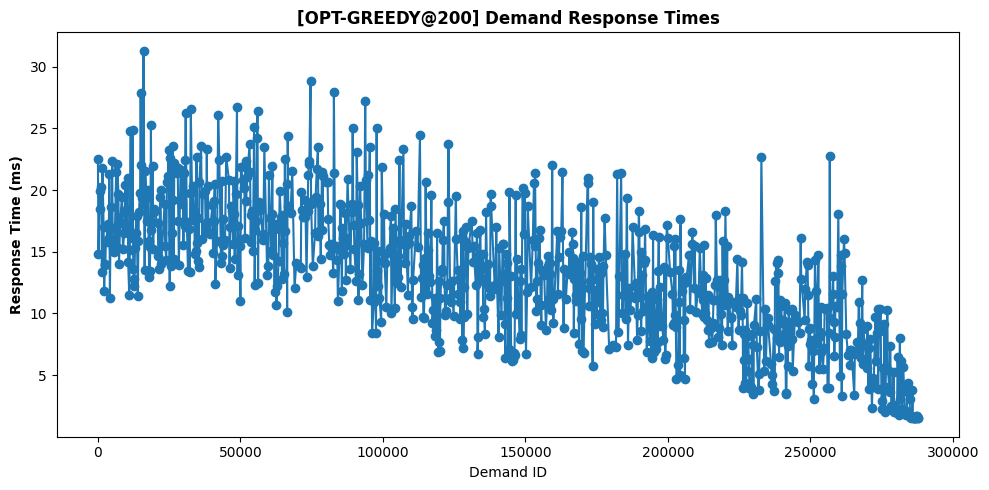

In [156]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

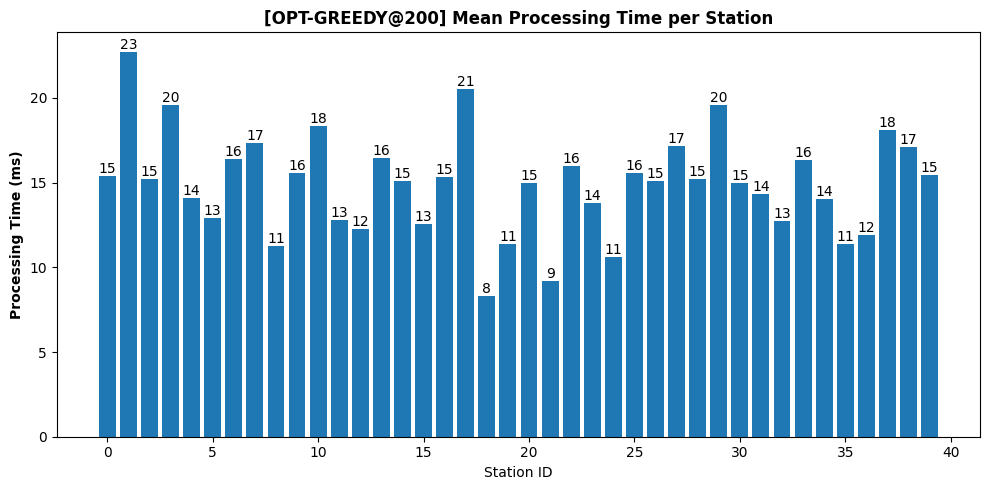

In [157]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [158]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/200cars


##### *Initialisation*

In [159]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [160]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-27 23:55:56.273 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-27 23:55:58.686 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-27 23:56:01.776 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-27 23:56:03.154 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-27 23:56:05.171 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-27 23:56:08.132 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-27 23:56:10.408 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-27 23:56:12.618 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-27 23:56:14.459 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-27 23:56:15.475 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-27 23:56:16.512 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [161]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 27.62 kWh
  Station 1: 74.53 kWh
  Station 2: 54.99 kWh
  Station 3: 33.89 kWh
  Station 4: 7.04 kWh
  Station 5: 17.78 kWh
  Station 6: 199.85 kWh
  Station 7: 13.22 kWh
  Station 8: 25.85 kWh
  Station 9: 65.67 kWh
  Station 10: 29.85 kWh
  Station 11: 44.20 kWh
  Station 12: 47.07 kWh
  Station 13: 33.52 kWh
  Station 14: 12.60 kWh
  Station 15: 75.11 kWh
  Station 16: 10.13 kWh
  Station 17: 9.46 kWh
  Station 18: 3.88 kWh
  Station 19: 48.39 kWh
  Station 20: 15.80 kWh
  Station 21: 6.65 kWh
  Station 22: 8.99 kWh
  Station 23: 10.35 kWh
  Station 24: 7.39 kWh
  Station 25: 105.21 kWh
  Station 26: 1.33 kWh
  Station 27: 155.05 kWh
  Station 28: 7.92 kWh
  Station 29: 102.41 kWh
  Station 30: 24.80 kWh
  Station 31: 256.02 kWh
  Station 32: 251.36 kWh
  Station 33: 104.33 kWh
  Station 34: 25.97 kWh
  Station 35: 188.46 kWh
  Station 36: 11.42 kWh
  Station 37: 2.08 kWh
  Station 38: 97.44 kWh
  Station 39

In [162]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

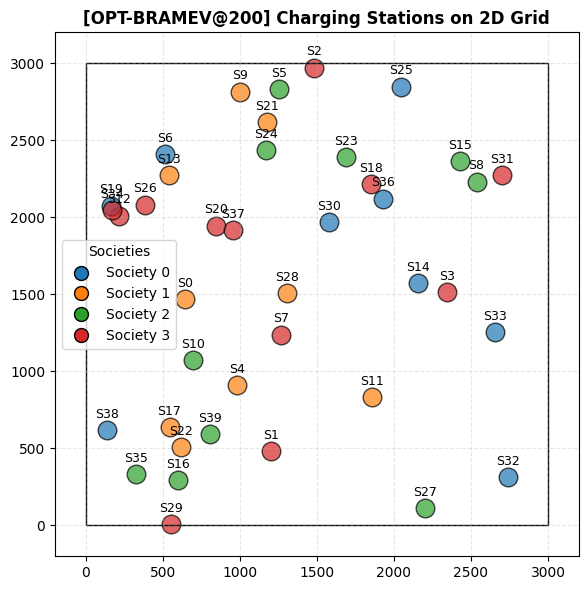

In [163]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

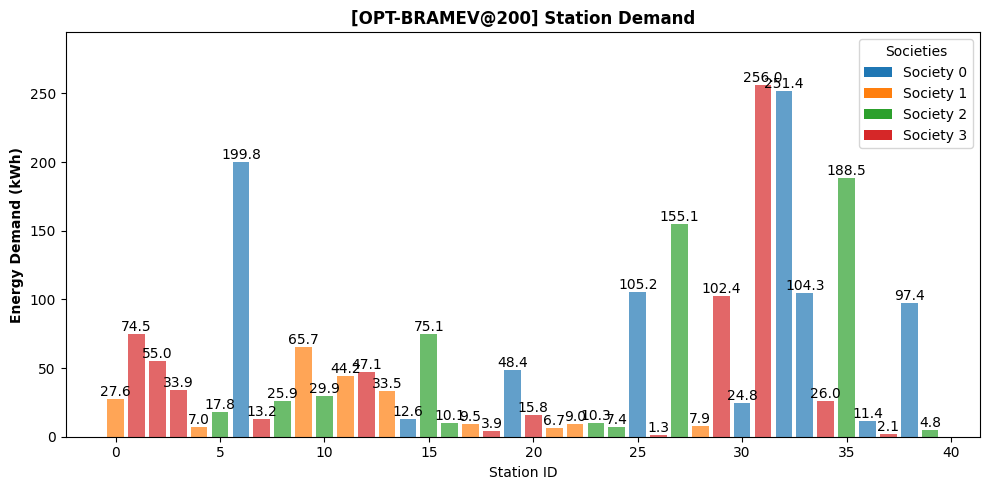

In [164]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

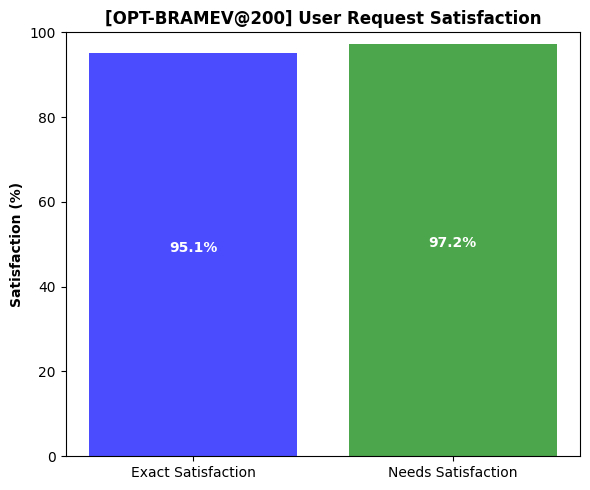

In [165]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

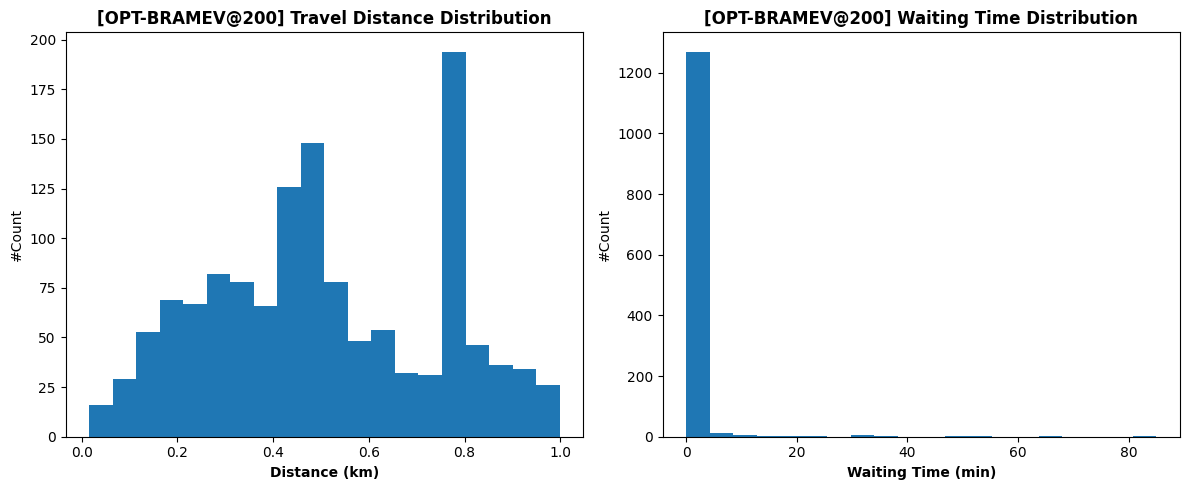

In [166]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

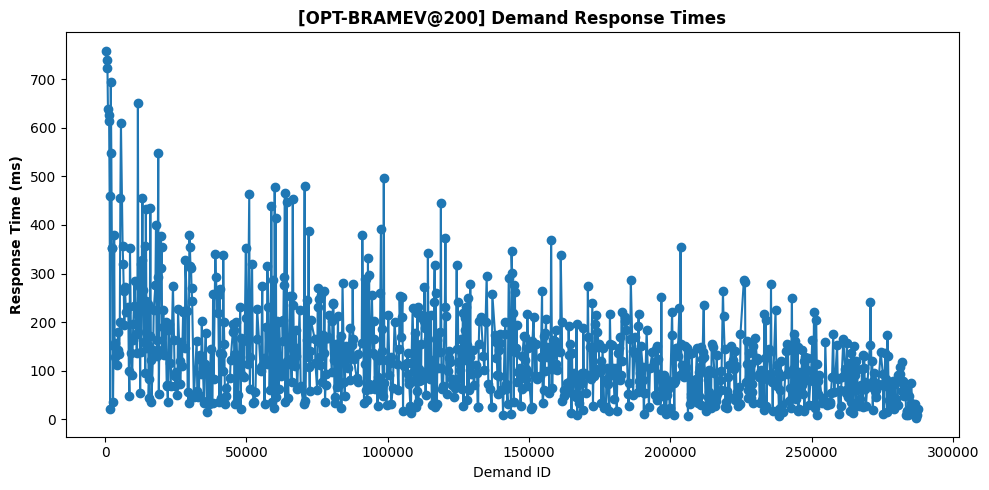

In [167]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

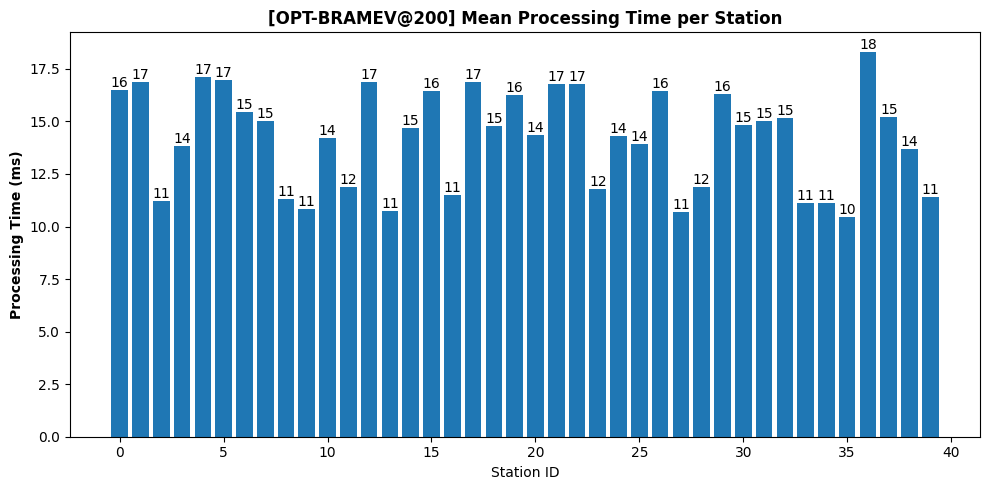

In [168]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [169]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

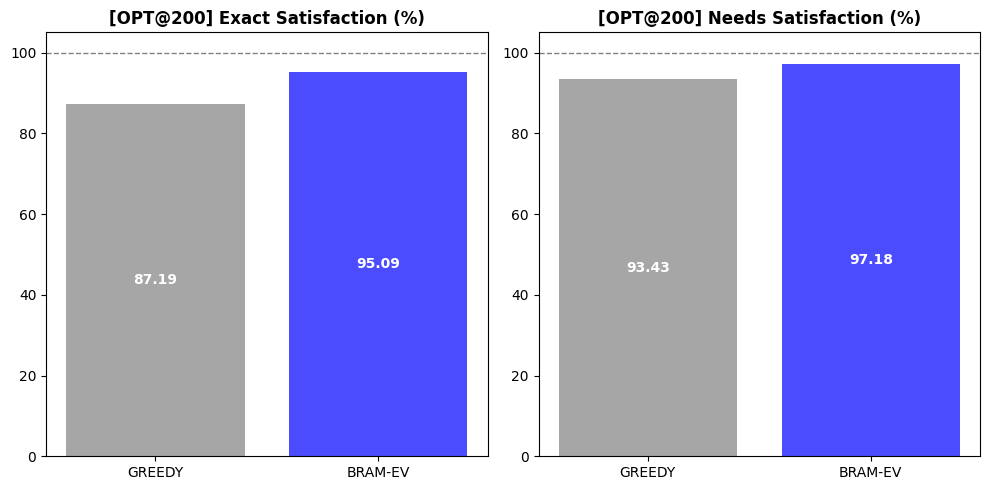

In [170]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

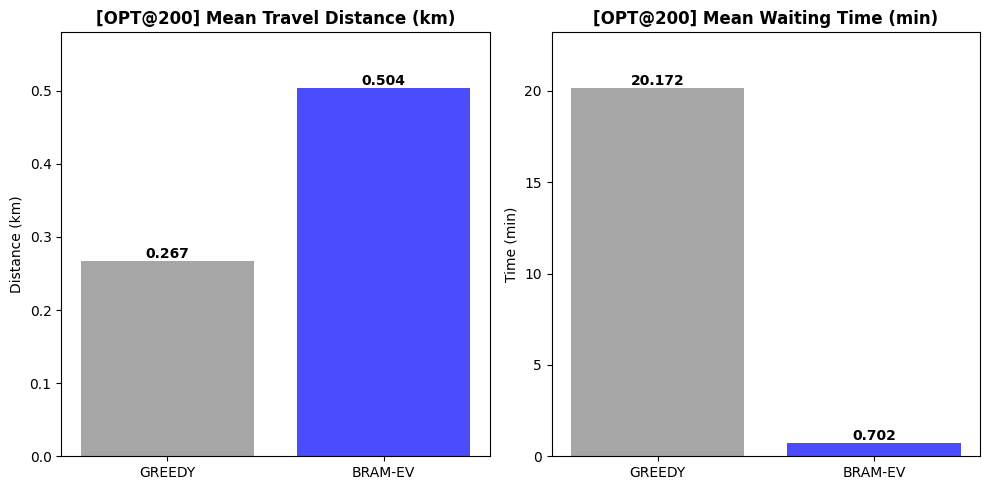

In [171]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

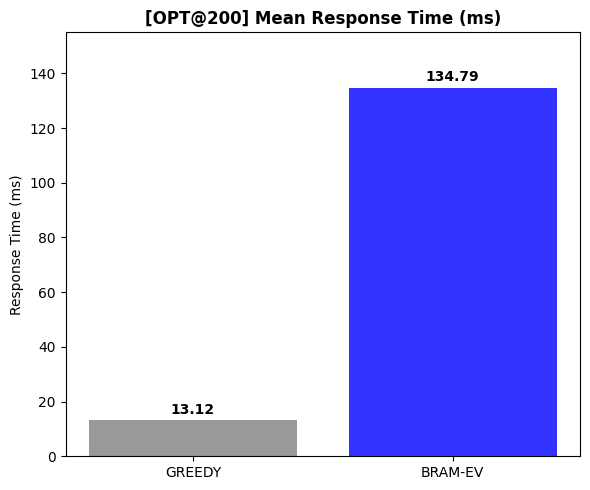

In [172]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [173]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [174]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/250cars


##### *Initialisation*

In [175]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [176]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-05-27 23:58:04.997 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-05-27 23:58:05.300 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-05-27 23:58:05.602 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-05-27 23:58:05.817 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-05-27 23:58:05.972 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-05-27 23:58:06.409 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-05-27 23:58:06.714 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-05-27 23:58:07.050 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-05-27 23:58:07.482 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-05-27 23:58:07.707 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-05-27 23:58:08.078 | IN

##### *Metrics*

In [177]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 10.30 kWh
  Station 1: 5.94 kWh
  Station 2: 34.83 kWh
  Station 3: 8.97 kWh
  Station 4: 322.86 kWh
  Station 5: 9.31 kWh
  Station 6: 305.06 kWh
  Station 7: 75.01 kWh
  Station 8: 59.49 kWh
  Station 9: 2.10 kWh
  Station 10: 5.53 kWh
  Station 11: 3.78 kWh
  Station 12: 1.62 kWh
  Station 13: 13.27 kWh
  Station 14: 24.82 kWh
  Station 15: 15.46 kWh
  Station 16: 5.51 kWh
  Station 17: 45.80 kWh
  Station 18: 10.41 kWh
  Station 19: 9.75 kWh
  Station 20: 97.98 kWh
  Station 21: 23.50 kWh
  Station 22: 382.95 kWh
  Station 23: 56.08 kWh
  Station 24: 5.40 kWh
  Station 25: 69.72 kWh
  Station 26: 125.10 kWh
  Station 27: 3.59 kWh
  Station 28: 11.43 kWh
  Station 29: 122.28 kWh
  Station 30: 8.48 kWh
  Station 31: 4.37 kWh
  Station 32: 337.12 kWh
  Station 33: 147.62 kWh
  Station 34: 37.82 kWh
  Station 35: 122.49 kWh
  Station 36: 11.18 kWh
  Station 37: 116.76 kWh
  Station 38: 7.58 kWh
  Station 39: 11

In [178]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

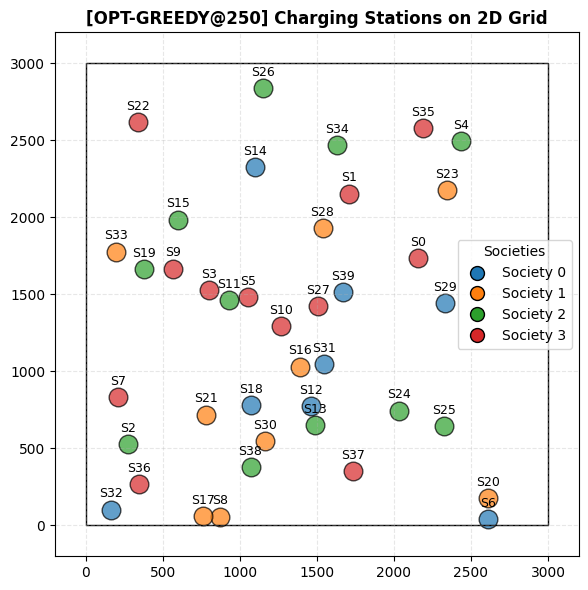

In [179]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

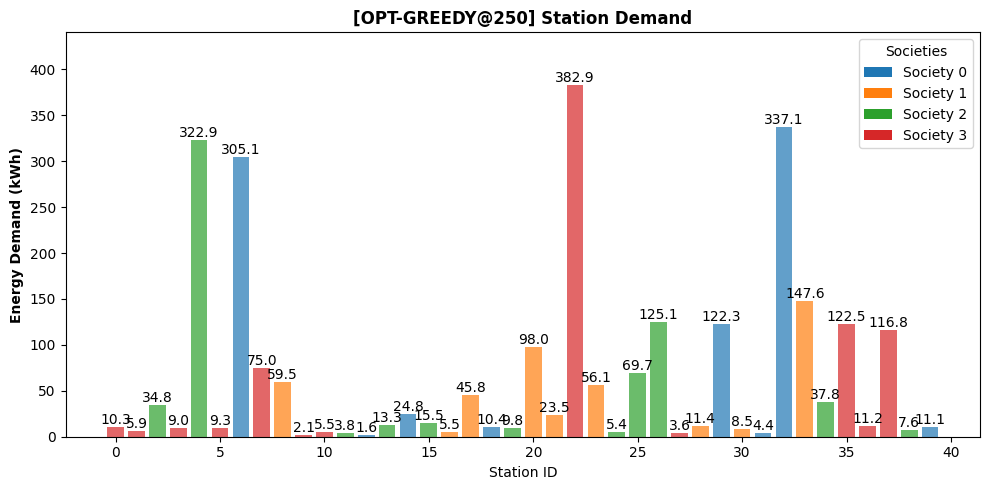

In [180]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

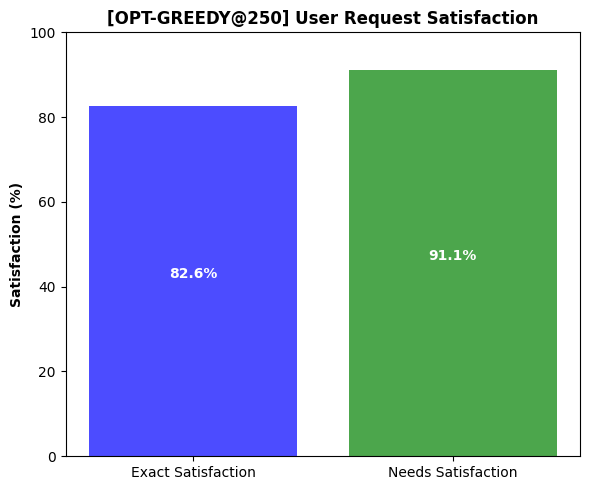

In [181]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

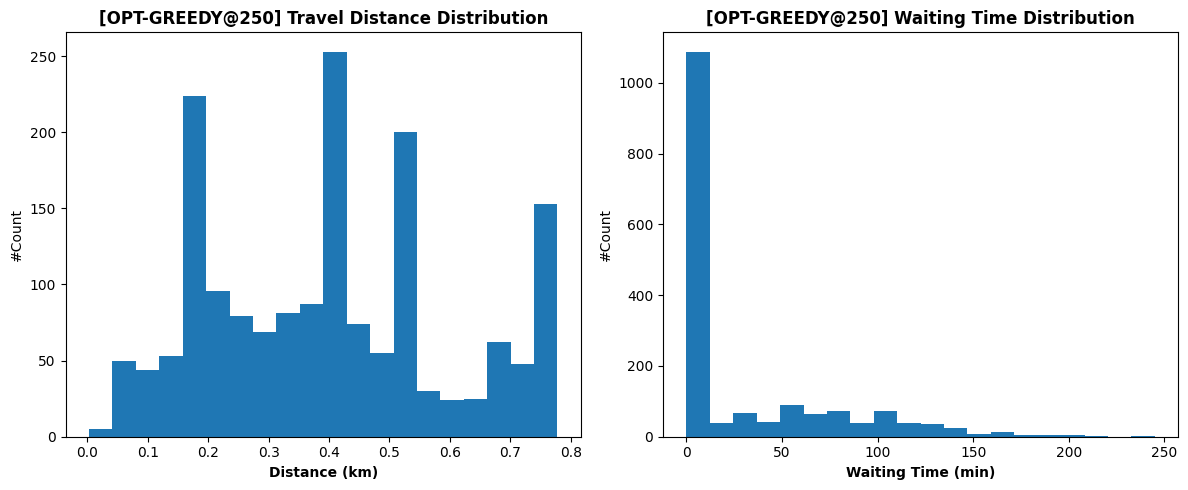

In [182]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

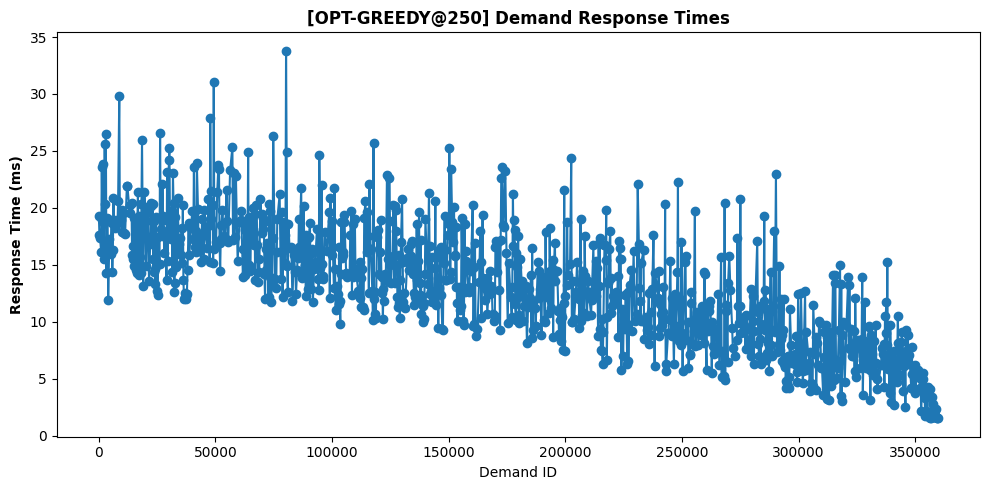

In [183]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

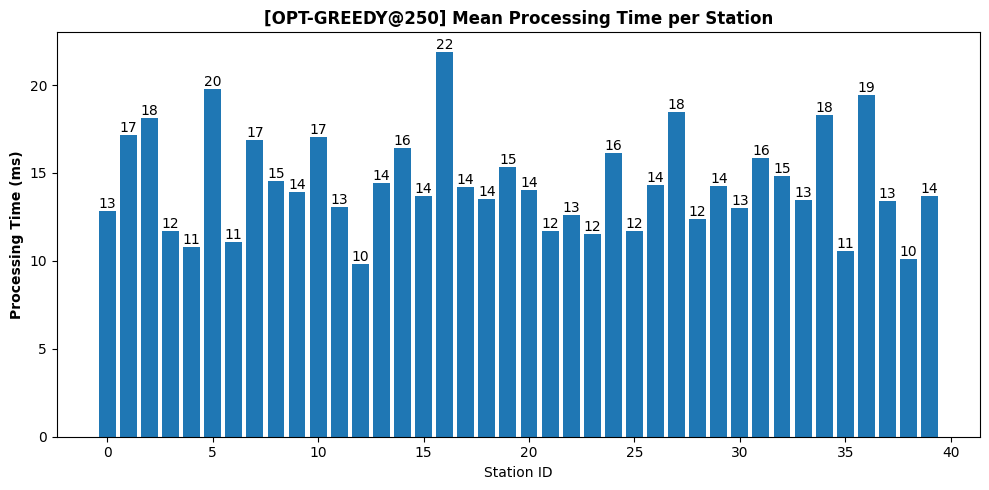

In [184]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [185]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/250cars


##### *Initialisation*

In [186]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [187]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-05-27 23:58:38.035 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-05-27 23:58:43.934 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-05-27 23:58:45.454 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-05-27 23:58:47.510 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-05-27 23:58:50.047 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-05-27 23:58:51.883 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-05-27 23:58:54.633 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-05-27 23:58:56.817 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-05-27 23:58:59.964 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-05-27 23:59:01.713 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-05-27 23:59:03.599 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-05

##### *Metrics*

In [188]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 30.37 kWh
  Station 1: 32.03 kWh
  Station 2: 24.86 kWh
  Station 3: 48.42 kWh
  Station 4: 63.58 kWh
  Station 5: 8.55 kWh
  Station 6: 28.21 kWh
  Station 7: 3.52 kWh
  Station 8: 58.48 kWh
  Station 9: 19.59 kWh
  Station 10: 33.18 kWh
  Station 11: 22.67 kWh
  Station 12: 83.29 kWh
  Station 13: 47.98 kWh
  Station 14: 12.81 kWh
  Station 15: 95.97 kWh
  Station 16: 92.12 kWh
  Station 17: 251.00 kWh
  Station 18: 15.22 kWh
  Station 19: 121.08 kWh
  Station 20: 5.47 kWh
  Station 21: 68.04 kWh
  Station 22: 264.13 kWh
  Station 23: 15.12 kWh
  Station 24: 111.62 kWh
  Station 25: 64.84 kWh
  Station 26: 33.02 kWh
  Station 27: 53.97 kWh
  Station 28: 43.94 kWh
  Station 29: 180.53 kWh
  Station 30: 3.63 kWh
  Station 31: 128.51 kWh
  Station 32: 238.96 kWh
  Station 33: 7.94 kWh
  Station 34: 191.18 kWh
  Station 35: 87.24 kWh
  Station 36: 72.38 kWh
  Station 37: 43.57 kWh
  Station 38: 9.01 kWh
  Station

In [189]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

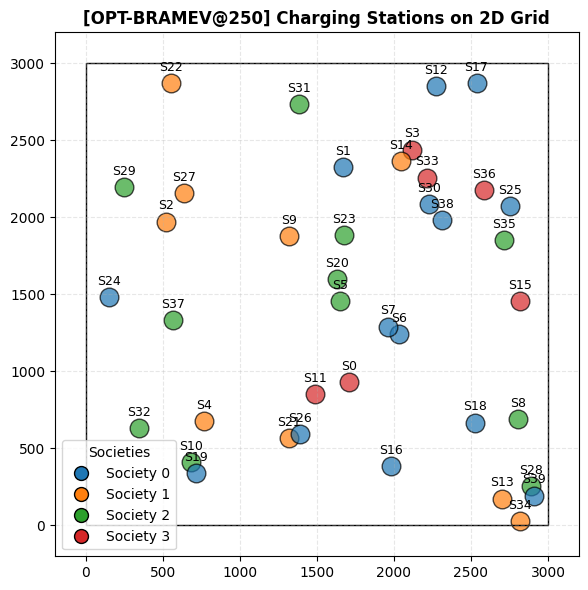

In [190]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

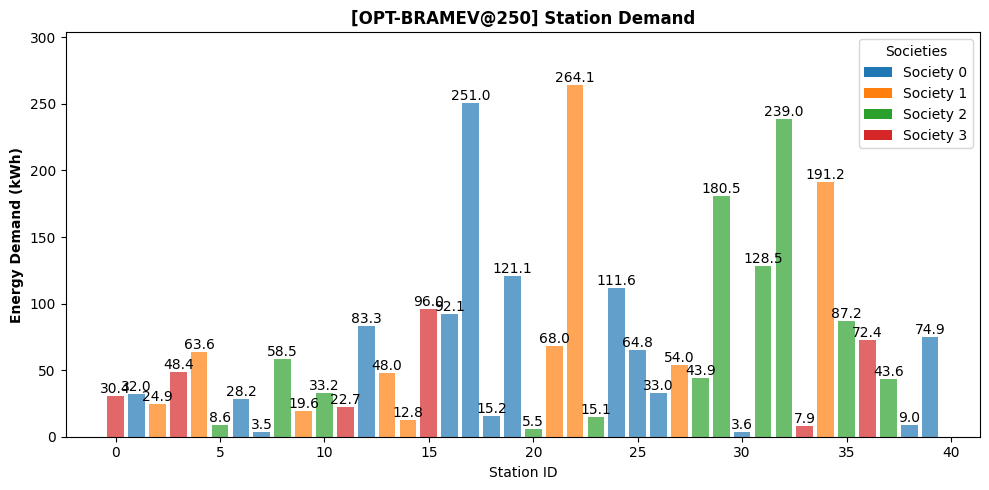

In [191]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

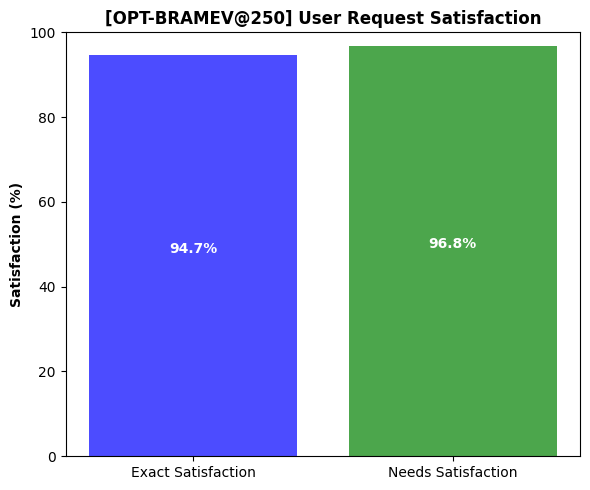

In [192]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

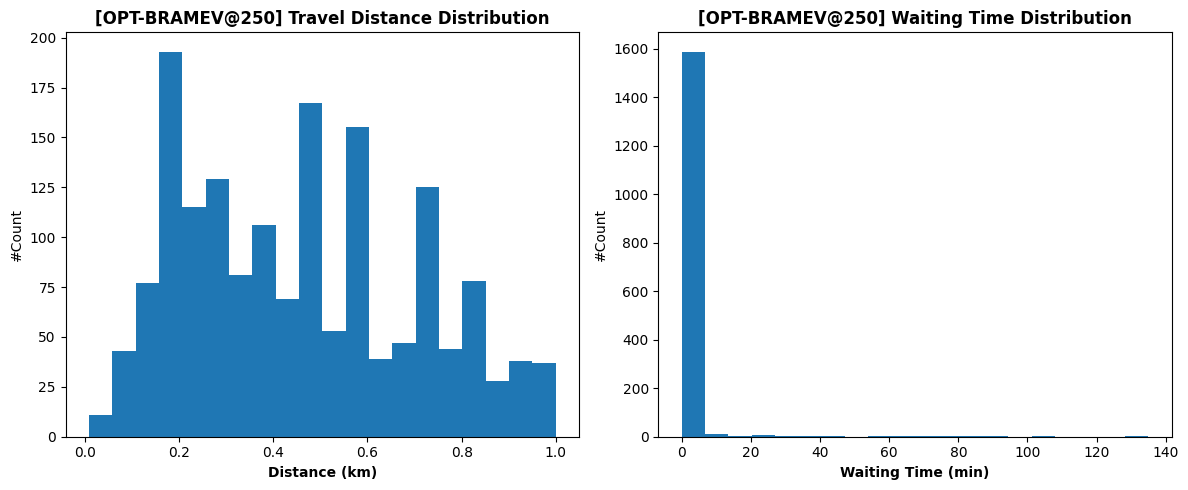

In [193]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

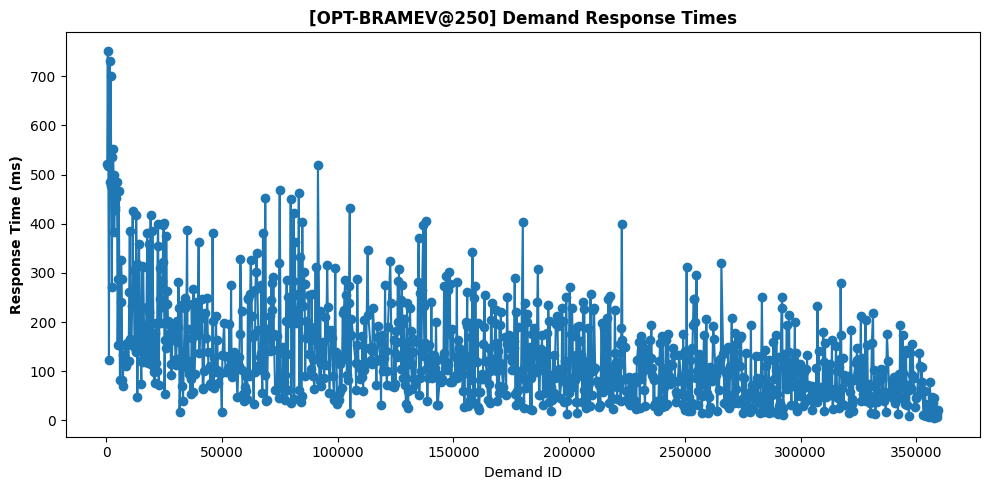

In [194]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

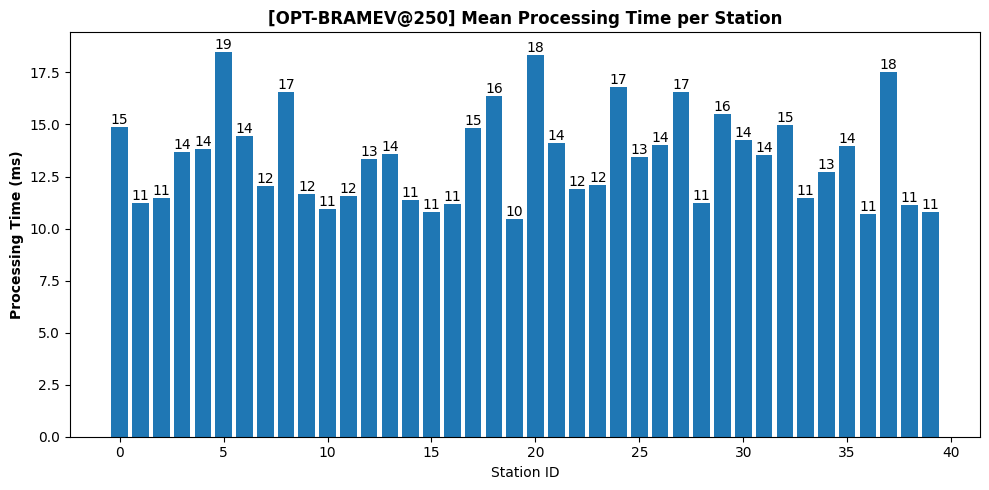

In [195]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [196]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

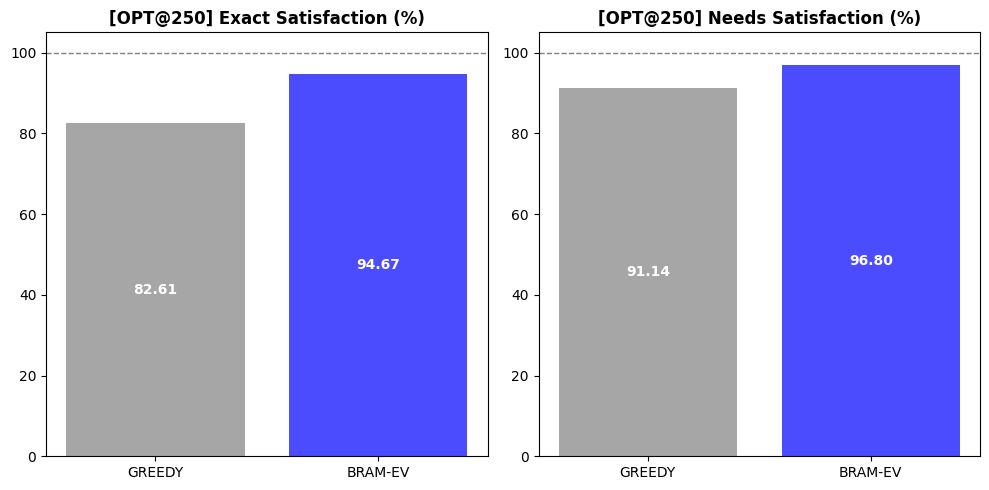

In [197]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

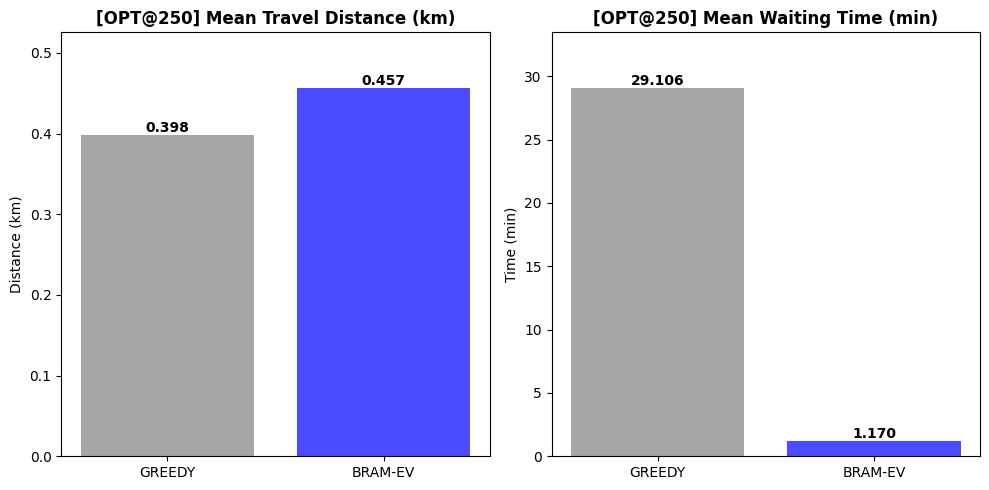

In [198]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

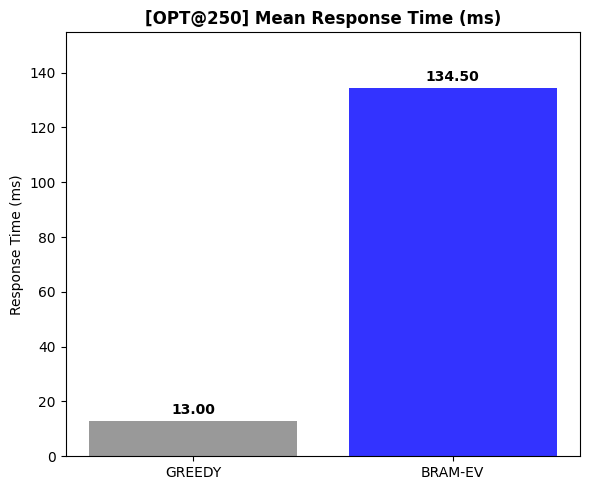

In [199]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

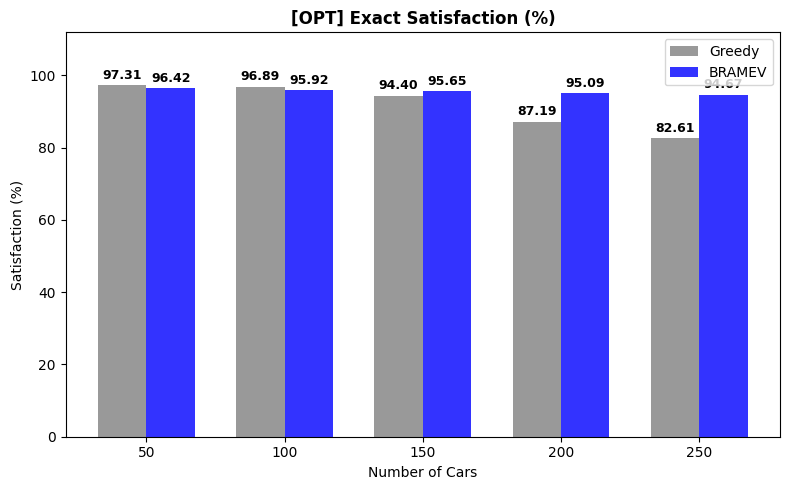

In [200]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

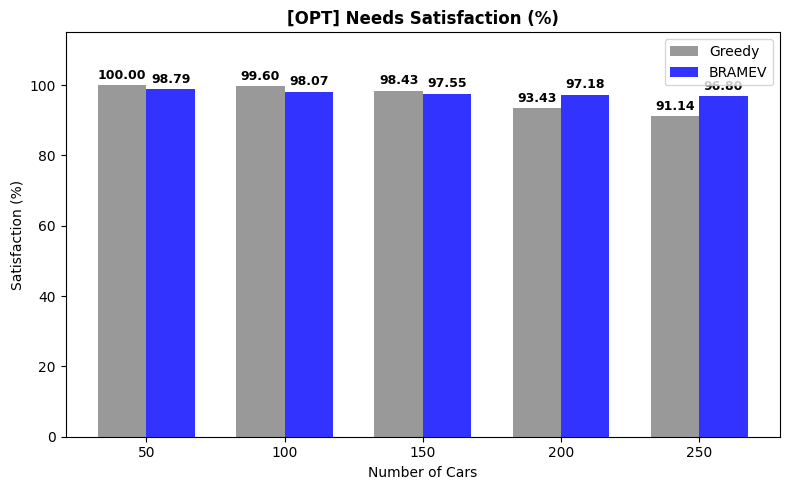

In [201]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

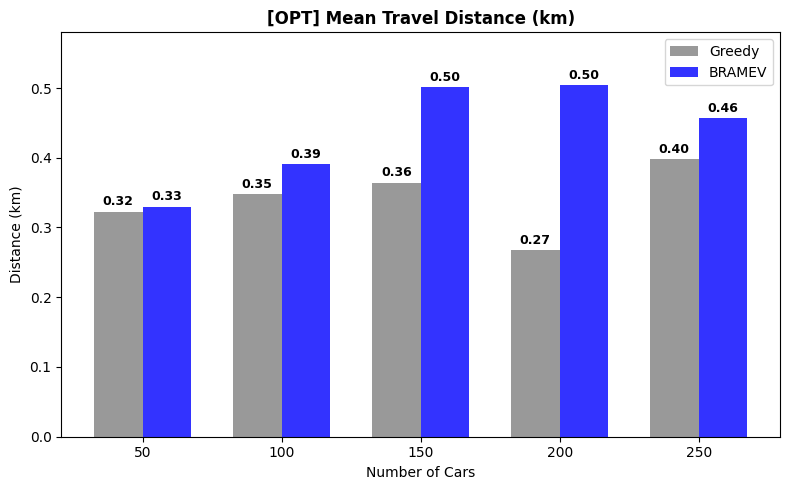

In [202]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


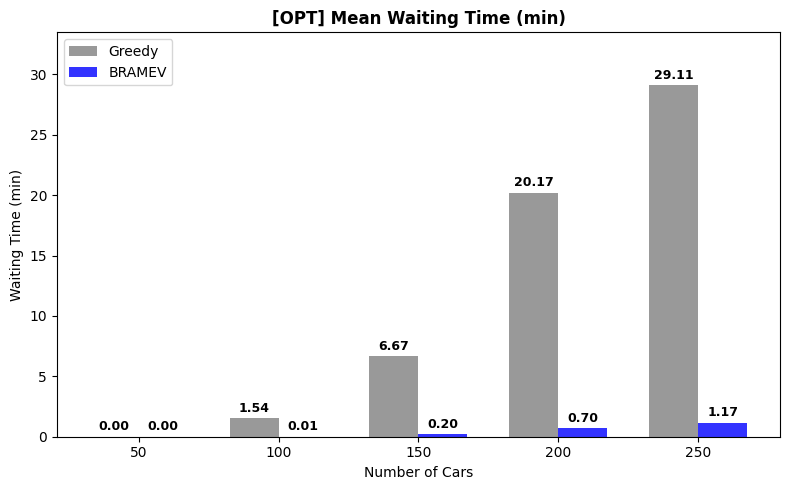

In [203]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


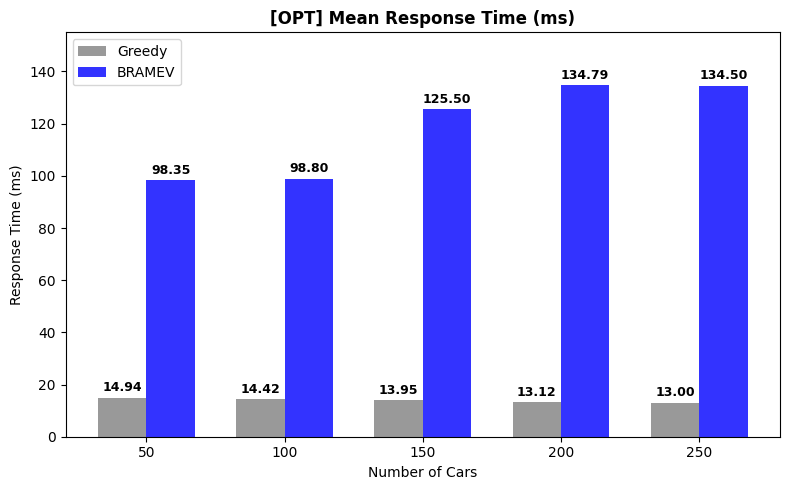

In [204]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
